# Two-Speed EV Shift-Speed Energy Optimization

This notebook evaluates how hysteresis shift thresholds change motor operating points, efficiency usage, and consumed motor input energy for the N603 drive cycle.

## Workflow

1. Configure vehicle, motor, gearbox, battery, and numerical parameters.
2. Validate and load the N603 drive cycle and efficiency map.
3. Calculate vehicle longitudinal dynamics.
4. Apply upshift/downshift hysteresis and show selected motor RPM, torque, and mechanical power.
5. Plot the gear-ratio torque-speed scatter and show how each load point moves between ratios.
6. Load the motor efficiency map, identify the high-efficiency operating zone, and overlay the ratio scatter.
7. Sweep candidate upshift speeds and compare consumed motor input energy without regeneration.
8. Verify representative cases, select the minimum-consumed-energy strategy, and export the results.

The analysis normalizes the supplied `Tiime[s]` and `Speed[kmph]` columns to internal `Time` and `Speed` names.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display
from matplotlib.ticker import MultipleLocator
from scipy.interpolate import RegularGridInterpolator, NearestNDInterpolator

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["grid.alpha"] = 0.3


## 1. Parameters


In [2]:
# ============================================================
# VEHICLE PARAMETERS
# ============================================================
vehicle_mass = 995.0          # kg
wheel_radius = 0.247          # m
Cd = 1.104                    # aerodynamic drag coefficient
frontal_area = 1.0            # m^2
Crr = 0.02                    # rolling resistance coefficient
air_density = 1.225           # kg/m^3
g = 9.81                      # m/s^2
road_grade_deg = 0.0          # degrees

# ============================================================
# GEAR RATIOS AND EFFICIENCIES
# ============================================================
G1 = 19.0
G2 = 11.0
eta_gear_1 = 0.97
eta_gear_2 = 0.97

# ============================================================
# MOTOR LIMITS
# ============================================================
motor_max_rpm = 10_000.0
motor_max_torque = 45.0       # Nm
motor_min_torque = -45.0      # Nm

# ============================================================
# ELECTRICAL LIMITS
# ============================================================
battery_voltage = 52     # V
battery_max_power = 15_000.0  # W, magnitude limit for motoring and regen

# ============================================================
# NUMERICAL AND MAP SETTINGS
# ============================================================
power_epsilon = 1.0           # W; efficiency is irrelevant below this power
minimum_efficiency = 0.01     # reject zero, negative, or corrupt efficiency

# If True, out-of-bound map queries are clamped to map boundaries.
allow_boundary_clamping = True

# If True, a missing linear-interpolation result uses the nearest valid map cell.
allow_nearest_fallback = True


## 2. Input files


In [3]:
cycle_file = <path-removed>efficiency_file = <path-removed>
if not cycle_file.exists():
    raise FileNotFoundError(f"Drive-cycle file not found: {cycle_file}")

if not efficiency_file.exists():
    raise FileNotFoundError(f"Efficiency-map file not found: {efficiency_file}")

print(f"Drive cycle: {cycle_file.name}")
print(f"Efficiency map: {efficiency_file.name}")

Drive cycle: N603_AMT_onroadrange_SpeedBased_.csv
Efficiency map: N603_42UH_230_Fineint_EfficiencyMap.xlsx


## 3. Load and clean the drive cycle


In [4]:
df_cycle = pd.read_csv(cycle_file)
df_cycle.columns = df_cycle.columns.astype(str).str.strip()

# Accept the supplied N603 names and normalize them for the analysis.
column_aliases = {
    "Time": ["Time", "Tiime[s]", "Time[s]"],
    "Speed": ["Speed", "Speed[kmph]", "Speed [km/h]", "Speed[km/h]"],
}
resolved_columns = {}
for canonical_name, aliases in column_aliases.items():
    matching_columns = [column for column in aliases if column in df_cycle.columns]
    if not matching_columns:
        raise ValueError(
            f"Could not find a {canonical_name} column. Available columns: {list(df_cycle.columns)}"
        )
    resolved_columns[canonical_name] = matching_columns[0]

df_cycle = df_cycle[[resolved_columns["Time"], resolved_columns["Speed"]]].copy()
df_cycle.columns = ["Time", "Speed"]
df_cycle["Time"] = pd.to_numeric(df_cycle["Time"], errors="coerce")
df_cycle["Speed"] = pd.to_numeric(df_cycle["Speed"], errors="coerce")
df_cycle = df_cycle.dropna().sort_values("Time")

# Average samples with duplicate timestamps so gradient calculation is stable.
df_cycle = df_cycle.groupby("Time", as_index=False)["Speed"].mean()

if len(df_cycle) < 3:
    raise ValueError("The drive cycle must contain at least three valid samples.")

if np.any(np.diff(df_cycle["Time"].to_numpy(dtype=float)) <= 0):
    raise ValueError("Time must be strictly increasing after cleaning.")

if (df_cycle["Speed"] < 0).any():
    raise ValueError("Vehicle speed contains negative values.")

display(df_cycle.head())
print(f"Source columns: {resolved_columns}")
print(f"Samples: {len(df_cycle):,}")
print(f"Duration: {df_cycle['Time'].iloc[-1] - df_cycle['Time'].iloc[0]:.2f} s")
print(f"Maximum speed: {df_cycle['Speed'].max():.2f} km/h")

,Time,Speed
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,0.0


Source columns: {'Time': 'Tiime[s]', 'Speed': 'Speed[kmph]'}
Samples: 28,368
Duration: 28367.00 s
Maximum speed: 42.26 km/h


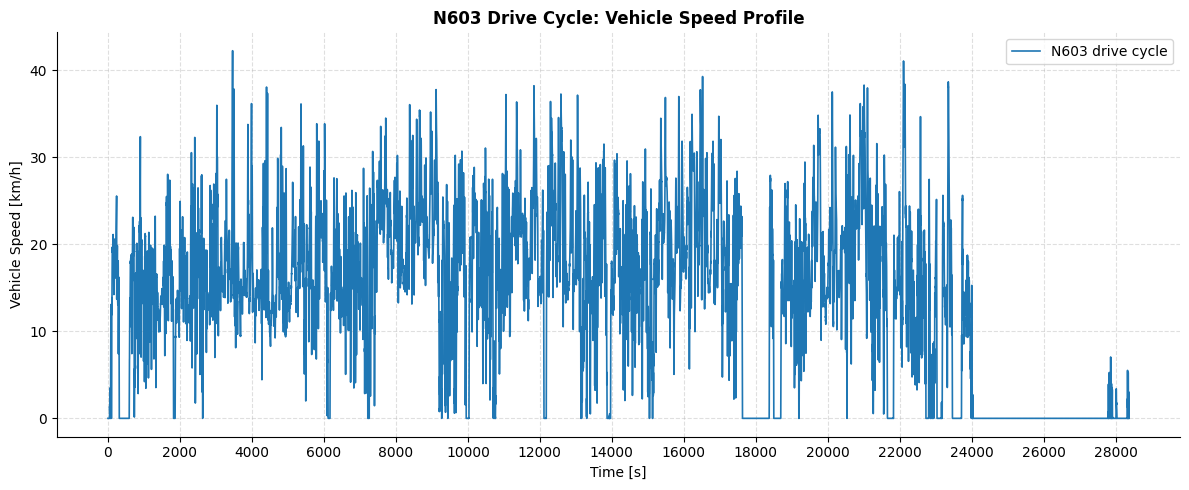

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_cycle["Time"], df_cycle["Speed"], linewidth=1.2, label="N603 drive cycle")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Vehicle Speed [km/h]")
ax.set_title("N603 Drive Cycle: Vehicle Speed Profile", fontweight="bold")
ax.xaxis.set_major_locator(MultipleLocator(2000))
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.grid(True, linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Vehicle longitudinal dynamics


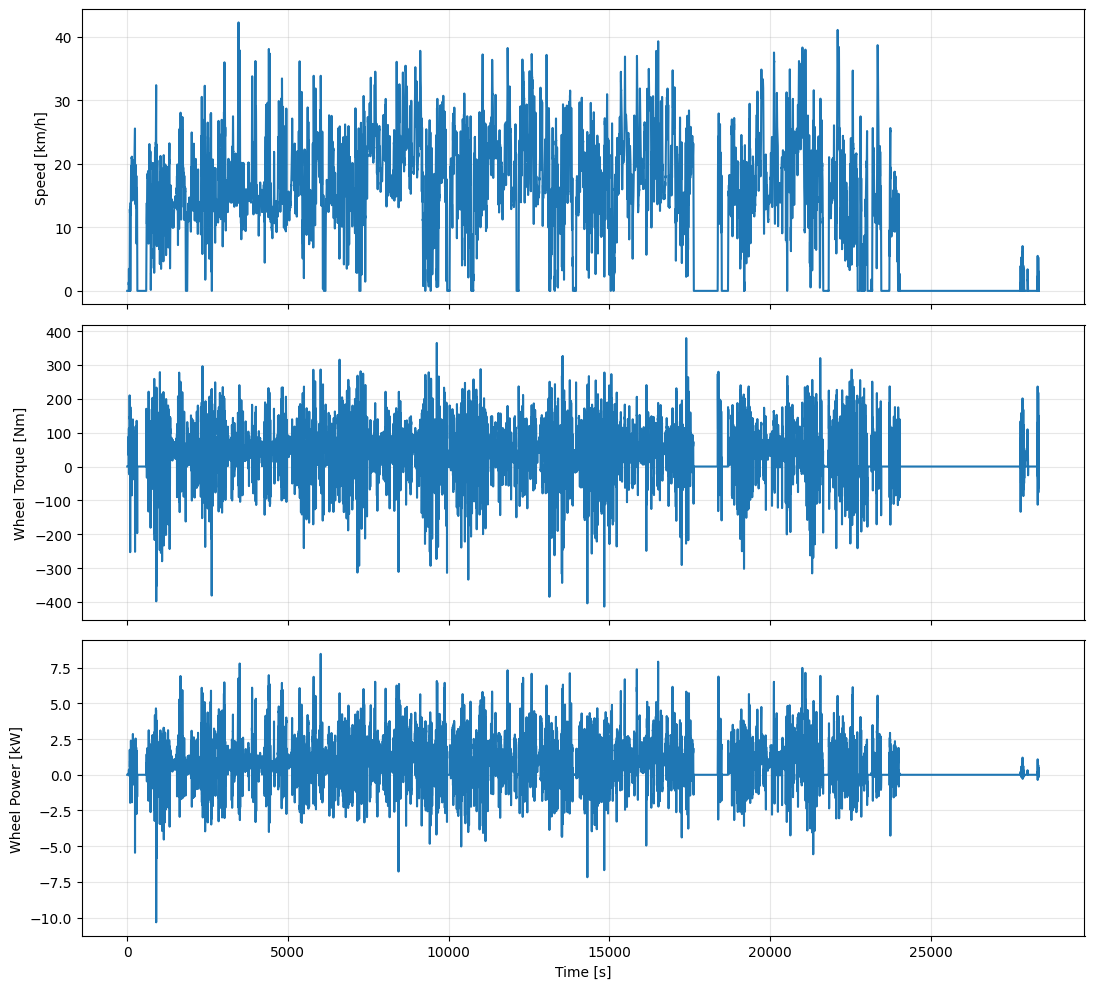

In [6]:
time = df_cycle["Time"].to_numpy(dtype=float)
speed_kmh = df_cycle["Speed"].to_numpy(dtype=float)
speed_ms = speed_kmh / 3.6

# Works correctly for nonuniform time intervals.
acceleration = np.gradient(speed_ms, time, edge_order=2)
grade_rad = np.deg2rad(road_grade_deg)

F_acc = vehicle_mass * acceleration
F_roll = vehicle_mass * g * Crr * np.cos(grade_rad) * (speed_ms > 0)
F_aero = 0.5 * air_density * Cd * frontal_area * speed_ms**2
F_grade = vehicle_mass * g * np.sin(grade_rad) * (speed_ms > 0)
F_total = F_acc + F_roll + F_aero + F_grade

wheel_torque = F_total * wheel_radius
wheel_omega = speed_ms / wheel_radius
wheel_rpm = wheel_omega * 60.0 / (2.0 * np.pi)
wheel_power = wheel_torque * wheel_omega

fig, ax = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
ax[0].plot(time, speed_kmh)
ax[0].set_ylabel("Speed [km/h]")
ax[1].plot(time, wheel_torque)
ax[1].set_ylabel("Wheel Torque [Nm]")
ax[2].plot(time, wheel_power / 1000.0)
ax[2].set_ylabel("Wheel Power [kW]")
ax[2].set_xlabel("Time [s]")

for axis in ax:
    axis.grid(True)

plt.tight_layout()
plt.show()


## 5. Upshift and downshift logic

The controller stays in Gear 1 until the vehicle reaches the upshift threshold, then changes to Gear 2. It returns to Gear 1 only when speed falls below the lower downshift threshold. This hysteresis prevents rapid gear toggling near one speed.

In [7]:
def calculate_motor_point(
    wheel_torque,
    wheel_rpm,
    wheel_power,
    gear_ratio,
    gearbox_efficiency,
):
    """Convert wheel operating points to motor-side values for one ratio."""
    motor_rpm = wheel_rpm * gear_ratio
    motor_torque = np.zeros_like(wheel_torque, dtype=float)

    motoring = wheel_power >= 0
    regen = wheel_power < 0
    motor_torque[motoring] = wheel_torque[motoring] / (gear_ratio * gearbox_efficiency)
    motor_torque[regen] = wheel_torque[regen] * gearbox_efficiency / gear_ratio
    motor_power = motor_torque * motor_rpm * (2.0 * np.pi / 60.0)
    return motor_rpm, motor_torque, motor_power

rpm_g1, torque_g1, motor_power_g1 = calculate_motor_point(
    wheel_torque, wheel_rpm, wheel_power, G1, eta_gear_1
)
rpm_g2, torque_g2, motor_power_g2 = calculate_motor_point(
    wheel_torque, wheel_rpm, wheel_power, G2, eta_gear_2
)

# Manager test baseline: upshift at 32 km/h and downshift at 22 km/h.
upshift_speed = 32.0
downshift_speed = 22.0
gear = np.ones_like(speed_kmh, dtype=int)
current_gear = 1

for index, vehicle_speed in enumerate(speed_kmh):
    if current_gear == 1 and vehicle_speed >= upshift_speed:
        current_gear = 2
    elif current_gear == 2 and vehicle_speed <= downshift_speed:
        current_gear = 1
    gear[index] = current_gear

use_g1 = gear == 1
selected_rpm = np.where(use_g1, rpm_g1, rpm_g2)
selected_torque = np.where(use_g1, torque_g1, torque_g2)
selected_motor_power = np.where(use_g1, motor_power_g1, motor_power_g2)
shift_idx = np.flatnonzero(np.diff(gear) != 0)
upshift_idx = shift_idx[gear[shift_idx + 1] == 2]
downshift_idx = shift_idx[gear[shift_idx + 1] == 1]

print(f"Manager baseline upshift threshold: {upshift_speed:.1f} km/h")
print(f"Manager baseline downshift threshold: {downshift_speed:.1f} km/h")
print(f"Upshift events: {len(upshift_idx)}")
print(f"Downshift events: {len(downshift_idx)}")

operating_points_df = pd.DataFrame({
    "Time [s]": time,
    "Vehicle Speed [km/h]": speed_kmh,
    "Gear": gear,
    "Motor RPM": selected_rpm,
    "Motor Torque [Nm]": selected_torque,
    "Motor Mechanical Power [kW]": selected_motor_power / 1000.0,
})
display(operating_points_df.head(10))

Manager baseline upshift threshold: 32.0 km/h
Manager baseline downshift threshold: 22.0 km/h
Upshift events: 44
Downshift events: 44


,Time [s],Vehicle Speed [km/h],Gear,Motor RPM,Motor Torque [Nm],Motor Mechanical Power [kW]
0,0.0,0.0,1,0.0,0.0,0.0
1,1.0,0.0,1,0.0,0.0,0.0
2,2.0,0.0,1,0.0,0.0,0.0
3,3.0,0.0,1,0.0,0.0,0.0
4,4.0,0.0,1,0.0,0.0,0.0
5,5.0,0.0,1,0.0,0.0,0.0
6,6.0,0.0,1,0.0,0.0,0.0
7,7.0,0.0,1,0.0,0.0,0.0
8,8.0,0.0,1,0.0,0.0,0.0
9,9.0,0.0,1,0.0,0.0,0.0


### Selected gear state and motor operating points

Each sample uses exactly one gear. At or below the downshift threshold, the controller is in Gear 1. Gear 2 is retained only while speed is above the downshift threshold and until the next upshift/downshift event. The following plots show the selected path, not both hypothetical ratios at every sample.

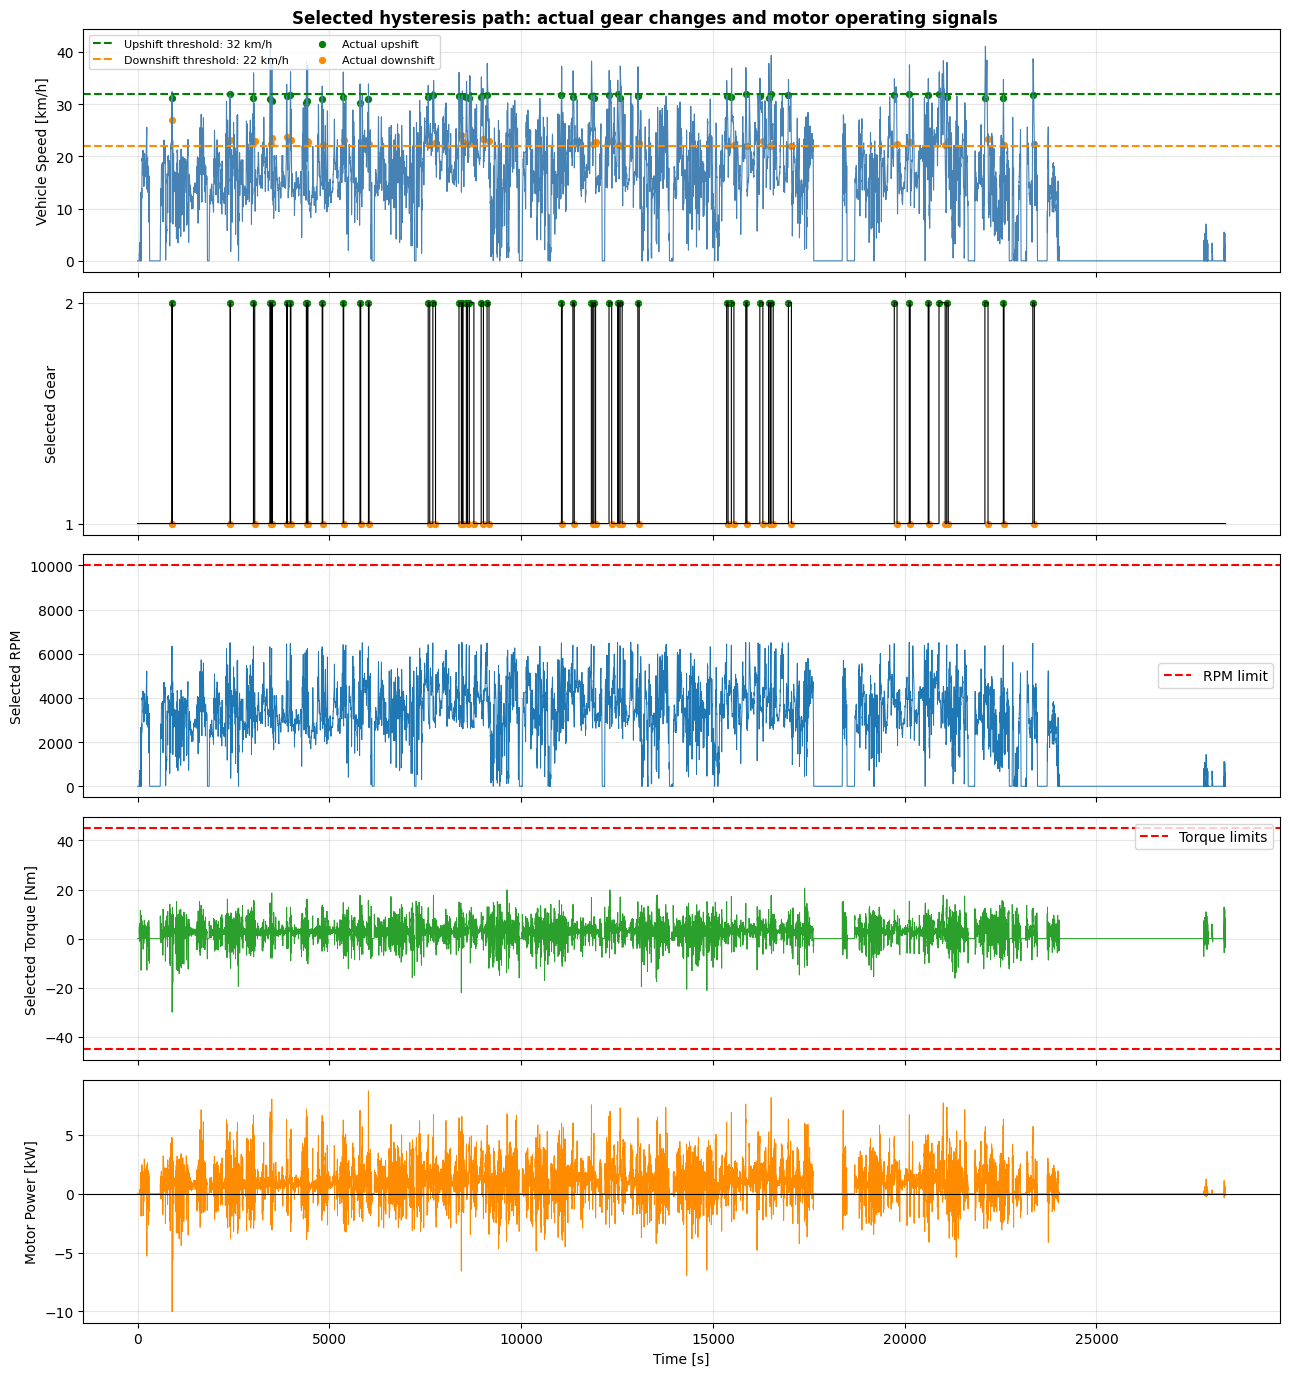

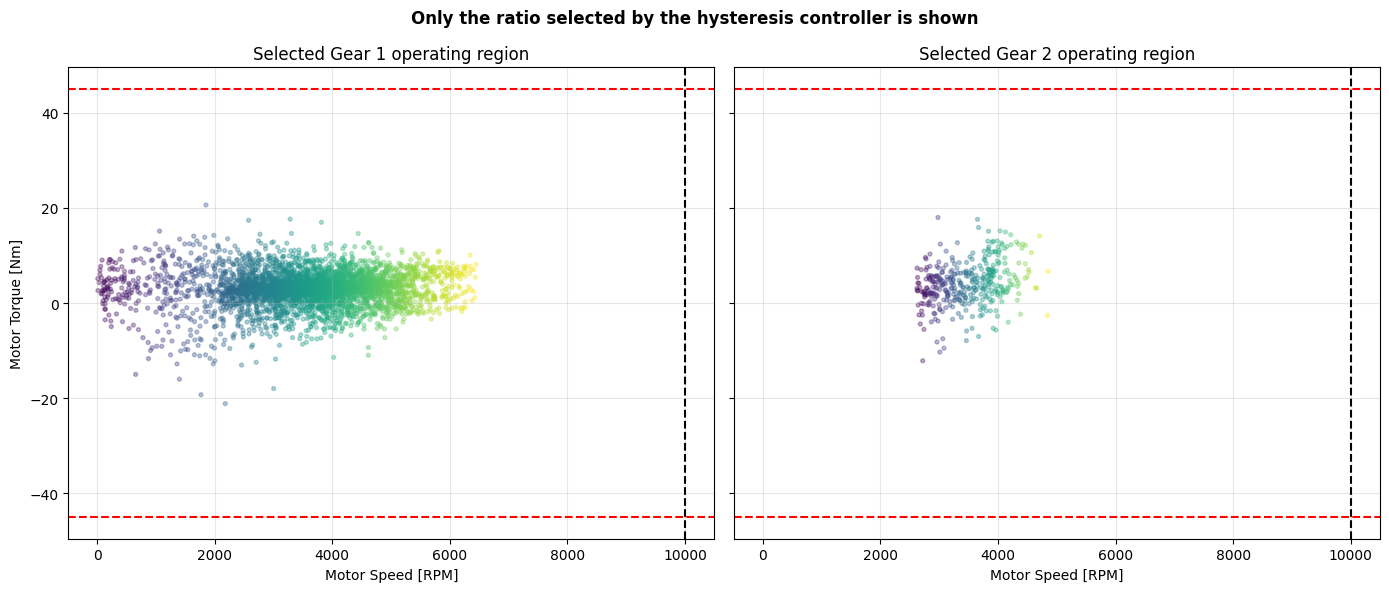

Selected active points: Gear 1 = 19,944, Gear 2 = 1,823
At or below 22 km/h, selected Gear 2 points: 0


In [8]:
upshift_times = time[upshift_idx]
downshift_times = time[downshift_idx]

fig, axes = plt.subplots(5, 1, figsize=(13, 14), sharex=True)
axes[0].plot(time, speed_kmh, color="steelblue", linewidth=0.8)
axes[0].axhline(upshift_speed, color="green", linestyle="--", label=f"Upshift threshold: {upshift_speed:g} km/h")
axes[0].axhline(downshift_speed, color="darkorange", linestyle="--", label=f"Downshift threshold: {downshift_speed:g} km/h")
axes[0].scatter(upshift_times, speed_kmh[upshift_idx], color="green", s=18, label="Actual upshift")
axes[0].scatter(downshift_times, speed_kmh[downshift_idx], color="darkorange", s=18, label="Actual downshift")
axes[0].set_ylabel("Vehicle Speed [km/h]")
axes[0].legend(ncol=2, fontsize=8)

axes[1].step(time, gear, where="post", color="black", linewidth=0.8)
axes[1].scatter(upshift_times, np.full(len(upshift_idx), 2), color="green", s=18)
axes[1].scatter(downshift_times, np.full(len(downshift_idx), 1), color="darkorange", s=18)
axes[1].set_ylabel("Selected Gear")
axes[1].set_yticks([1, 2])

axes[2].plot(time, selected_rpm, color="tab:blue", linewidth=0.7)
axes[2].axhline(motor_max_rpm, color="red", linestyle="--", label="RPM limit")
axes[2].set_ylabel("Selected RPM")
axes[2].legend()

axes[3].plot(time, selected_torque, color="tab:green", linewidth=0.7)
axes[3].axhline(motor_max_torque, color="red", linestyle="--", label="Torque limits")
axes[3].axhline(motor_min_torque, color="red", linestyle="--")
axes[3].set_ylabel("Selected Torque [Nm]")
axes[3].legend()

axes[4].plot(time, selected_motor_power / 1000.0, color="darkorange", linewidth=0.7)
axes[4].axhline(0, color="black", linewidth=0.8)
axes[4].set_ylabel("Motor Power [kW]")
axes[4].set_xlabel("Time [s]")

for axis in axes:
    axis.grid(True, alpha=0.3)
fig.suptitle("Selected hysteresis path: actual gear changes and motor operating signals", fontweight="bold")
plt.tight_layout()
plt.show()

# Plot only the operating points selected by the controller.
active_points = np.abs(wheel_power) > power_epsilon
selected_gear1 = active_points & (gear == 1)
selected_gear2 = active_points & (gear == 2)
plot_stride = max(1, int(np.ceil(np.sum(active_points) / 5000)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
axes[0].scatter(rpm_g1[selected_gear1][::plot_stride], torque_g1[selected_gear1][::plot_stride], c=speed_kmh[selected_gear1][::plot_stride], cmap="viridis", s=8, alpha=0.35, label="Selected Gear 1")
axes[0].set_title("Selected Gear 1 operating region")
axes[1].scatter(rpm_g2[selected_gear2][::plot_stride], torque_g2[selected_gear2][::plot_stride], c=speed_kmh[selected_gear2][::plot_stride], cmap="viridis", s=8, alpha=0.35, label="Selected Gear 2")
axes[1].set_title("Selected Gear 2 operating region")
for axis in axes:
    axis.axhline(motor_max_torque, color="red", linestyle="--")
    axis.axhline(motor_min_torque, color="red", linestyle="--")
    axis.axvline(motor_max_rpm, color="black", linestyle="--")
    axis.set_xlabel("Motor Speed [RPM]")
    axis.grid(True, alpha=0.3)
axes[0].set_ylabel("Motor Torque [Nm]")
fig.suptitle("Only the ratio selected by the hysteresis controller is shown", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Selected active points: Gear 1 = {np.sum(selected_gear1):,}, Gear 2 = {np.sum(selected_gear2):,}")
print(f"At or below {downshift_speed:g} km/h, selected Gear 2 points: {np.sum(active_points & (speed_kmh <= downshift_speed) & (gear == 2)):,}")

## 6. Selected motor torque-speed map and shift-state view

This section shows the operating points actually selected by the controller. The two gear-ratio calculations are not plotted as simultaneous alternatives. The adjacent speed/gear panel explains when each point belongs to Gear 1 or Gear 2.

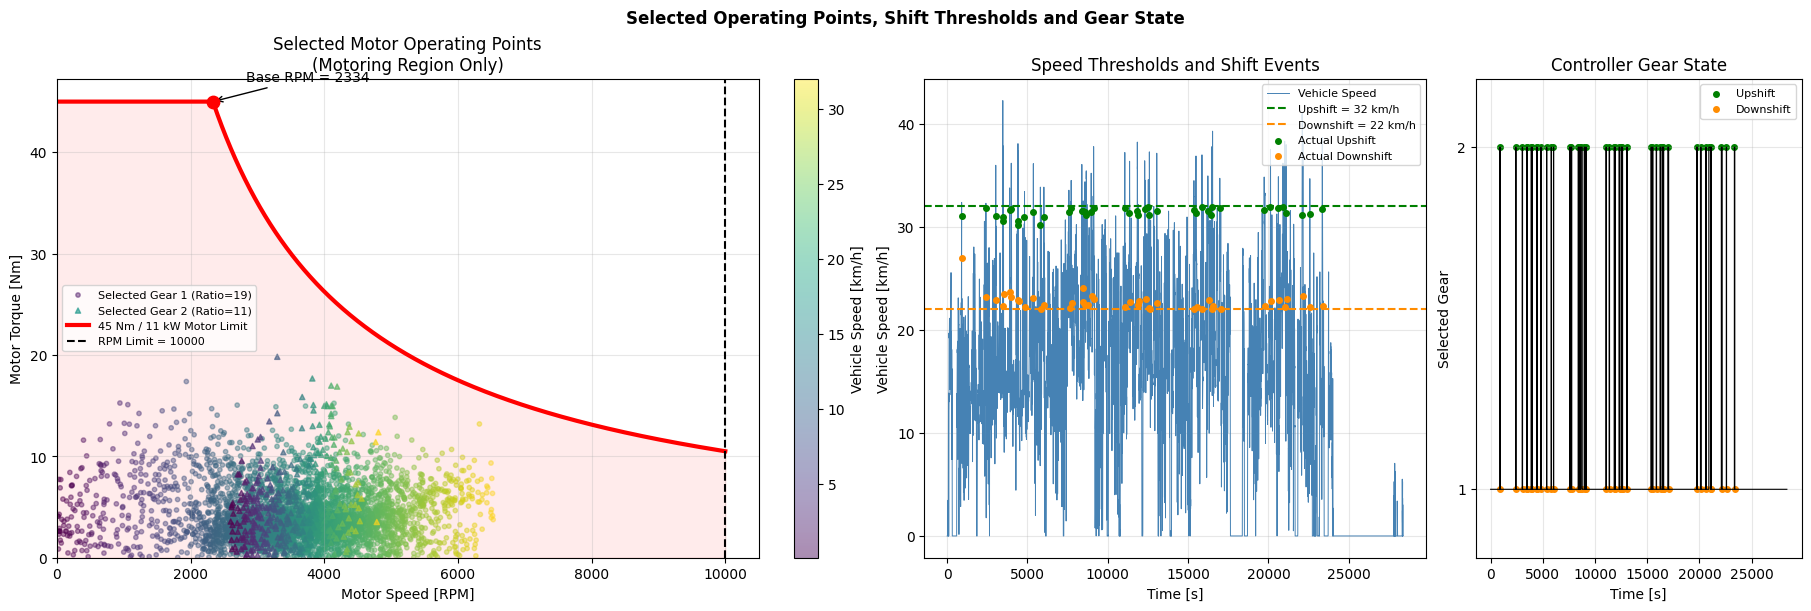

Motor peak torque      : 45.0 Nm
Motor peak power       : 11.0 kW
Base speed             : 2334 RPM
Selected active points: Gear 1 = 16,777, Gear 2 = 1,559
Selected Gear 2 points at or below 22 km/h: 0


In [16]:
# ==========================================================
# Plot selected points and shifting behaviour
# ==========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    gridspec_kw={"width_ratios": [1.4, 1, 0.65]},
    constrained_layout=True,
)

# ==========================================================
# PANEL 1
# Selected motor operating points
# Positive torque only (no regen)
# ==========================================================

selected_gear1_pos = selected_gear1 & (torque_g1 > 0)
selected_gear2_pos = selected_gear2 & (torque_g2 > 0)

total_points = (
    np.sum(selected_gear1_pos)
    + np.sum(selected_gear2_pos)
)

selected_plot_stride = max(
    1,
    int(np.ceil(total_points / 6000))
)

gear1_indices = np.flatnonzero(selected_gear1_pos)[::selected_plot_stride]
gear2_indices = np.flatnonzero(selected_gear2_pos)[::selected_plot_stride]

# ----------------------------------------------------------
# Motor envelope
# ----------------------------------------------------------

peak_torque = 45.0      # Nm
peak_power_kw = 11.0    # kW

base_rpm = 9550 * peak_power_kw / peak_torque

rpm_curve = np.linspace(
    1,
    motor_max_rpm,
    2000
)

torque_envelope = np.where(
    rpm_curve <= base_rpm,
    peak_torque,
    (9550 * peak_power_kw) / rpm_curve
)

torque_envelope = np.minimum(
    torque_envelope,
    peak_torque
)

# ----------------------------------------------------------
# Gear 1 points
# ----------------------------------------------------------

gear1_scatter = axes[0].scatter(
    rpm_g1[gear1_indices],
    torque_g1[gear1_indices],
    c=speed_kmh[gear1_indices],
    cmap="viridis",
    marker="o",
    s=10,
    alpha=0.45,
    label=f"Selected Gear 1 (Ratio={G1:g})",
)

# ----------------------------------------------------------
# Gear 2 points
# ----------------------------------------------------------

axes[0].scatter(
    rpm_g2[gear2_indices],
    torque_g2[gear2_indices],
    c=speed_kmh[gear2_indices],
    cmap="viridis",
    marker="^",
    s=14,
    alpha=0.65,
    label=f"Selected Gear 2 (Ratio={G2:g})",
)

# ----------------------------------------------------------
# Motor capability curve
# ----------------------------------------------------------

axes[0].plot(
    rpm_curve,
    torque_envelope,
    color="red",
    linewidth=3,
    label="45 Nm / 11 kW Motor Limit",
)

axes[0].fill_between(
    rpm_curve,
    0,
    torque_envelope,
    color="red",
    alpha=0.08,
)

# Base speed marker
axes[0].scatter(
    [base_rpm],
    [peak_torque],
    color="red",
    s=80,
    zorder=10,
)

axes[0].annotate(
    f"Base RPM = {base_rpm:.0f}",
    xy=(base_rpm, peak_torque),
    xytext=(base_rpm + 500, peak_torque + 2),
    arrowprops=dict(arrowstyle="->"),
)

# RPM limit
axes[0].axvline(
    motor_max_rpm,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"RPM Limit = {motor_max_rpm:.0f}",
)

axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)

axes[0].set_xlabel("Motor Speed [RPM]")
axes[0].set_ylabel("Motor Torque [Nm]")

axes[0].set_title(
    "Selected Motor Operating Points\n(Motoring Region Only)"
)

axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

fig.colorbar(
    gear1_scatter,
    ax=axes[0],
    label="Vehicle Speed [km/h]",
)

# ==========================================================
# PANEL 2
# Vehicle speed and shifting thresholds
# ==========================================================

axes[1].plot(
    time,
    speed_kmh,
    color="steelblue",
    linewidth=0.7,
    label="Vehicle Speed"
)

axes[1].axhline(
    upshift_speed,
    color="green",
    linestyle="--",
    label=f"Upshift = {upshift_speed:g} km/h"
)

axes[1].axhline(
    downshift_speed,
    color="darkorange",
    linestyle="--",
    label=f"Downshift = {downshift_speed:g} km/h"
)

axes[1].scatter(
    upshift_times,
    speed_kmh[upshift_idx],
    color="green",
    s=16,
    zorder=4,
    label="Actual Upshift"
)

axes[1].scatter(
    downshift_times,
    speed_kmh[downshift_idx],
    color="darkorange",
    s=16,
    zorder=4,
    label="Actual Downshift"
)

axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Vehicle Speed [km/h]")

axes[1].set_title(
    "Speed Thresholds and Shift Events"
)

axes[1].grid(True, alpha=0.3)
axes[1].legend(
    fontsize=8,
    loc="upper right"
)

# ==========================================================
# PANEL 3
# Gear state
# ==========================================================

axes[2].step(
    time,
    gear,
    where="post",
    color="black",
    linewidth=0.8,
)

axes[2].scatter(
    upshift_times,
    np.full(len(upshift_idx), 2),
    color="green",
    s=16,
    label="Upshift",
)

axes[2].scatter(
    downshift_times,
    np.full(len(downshift_idx), 1),
    color="darkorange",
    s=16,
    label="Downshift",
)

axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Selected Gear")

axes[2].set_yticks([1, 2])
axes[2].set_ylim(0.8, 2.2)

axes[2].set_title(
    "Controller Gear State"
)

axes[2].grid(True, alpha=0.3)
axes[2].legend(
    fontsize=8,
    loc="upper right"
)

# ==========================================================
# Overall title
# ==========================================================

fig.suptitle(
    "Selected Operating Points, Shift Thresholds and Gear State",
    fontweight="bold",
)

plt.show()

# ==========================================================
# Summary
# ==========================================================

print(f"Motor peak torque      : {peak_torque:.1f} Nm")
print(f"Motor peak power       : {peak_power_kw:.1f} kW")
print(f"Base speed             : {base_rpm:.0f} RPM")

print(
    f"Selected active points: "
    f"Gear 1 = {np.sum(selected_gear1_pos):,}, "
    f"Gear 2 = {np.sum(selected_gear2_pos):,}"
)

print(
    f"Selected Gear 2 points at or below "
    f"{downshift_speed:g} km/h: "
    f"{np.sum(active_points & (speed_kmh <= downshift_speed) & (gear == 2)):,}"
)

## 8. Load and validate the motor-efficiency map

The supplied efficiency map contains nonnegative torque data, so it directly describes motoring operation. For signed plots only, the map is mirrored about zero torque to represent regeneration: $\eta(-T, n) = \eta(|T|, n)$. This is an assumption because no separate regenerative efficiency map was supplied. The interpolation function uses the same absolute-torque assumption.

In [10]:
df_eff_raw = pd.read_excel(efficiency_file, header=None)
display(df_eff_raw.head())

rpm_grid = pd.to_numeric(
    df_eff_raw.iloc[0, 1:], errors="coerce"
).to_numpy(dtype=float)

torque_grid = pd.to_numeric(
    df_eff_raw.iloc[1:, 0], errors="coerce"
).to_numpy(dtype=float)

eff_map = df_eff_raw.iloc[1:, 1:].apply(
    pd.to_numeric, errors="coerce"
).to_numpy(dtype=float)

# Remove fully blank RPM-axis columns and torque-axis rows.
valid_rpm_columns = np.isfinite(rpm_grid)
valid_torque_rows = np.isfinite(torque_grid)

rpm_grid = rpm_grid[valid_rpm_columns]
torque_grid = torque_grid[valid_torque_rows]
eff_map = eff_map[np.ix_(valid_torque_rows, valid_rpm_columns)]

if eff_map.shape != (len(torque_grid), len(rpm_grid)):
    raise ValueError("Efficiency-map dimensions do not match its axes.")

finite_raw_efficiency = eff_map[np.isfinite(eff_map)]

if finite_raw_efficiency.size == 0:
    raise ValueError("The efficiency map contains no numeric efficiency values.")

# Convert percentage data, such as 90, to fractional data, such as 0.90.
if np.nanmedian(finite_raw_efficiency) > 1.5:
    eff_map = eff_map / 100.0

# RegularGridInterpolator requires strictly ascending axes.
torque_order = np.argsort(torque_grid)
rpm_order = np.argsort(rpm_grid)

torque_grid = torque_grid[torque_order]
rpm_grid = rpm_grid[rpm_order]
eff_map = eff_map[np.ix_(torque_order, rpm_order)]

if np.any(np.diff(torque_grid) <= 0):
    raise ValueError("Torque-axis values must be unique and strictly increasing.")

if np.any(np.diff(rpm_grid) <= 0):
    raise ValueError("RPM-axis values must be unique and strictly increasing.")

# Preserve missing map cells as NaN. Reject physically invalid efficiencies.
eff_map[(eff_map < minimum_efficiency) | (eff_map > 1.0)] = np.nan

print(f"RPM range: {rpm_grid.min():.2f} to {rpm_grid.max():.2f} rpm")
print(f"Torque range: {torque_grid.min():.2f} to {torque_grid.max():.2f} Nm")
print(f"Efficiency range: {np.nanmin(eff_map):.4f} to {np.nanmax(eff_map):.4f}")
print(f"Efficiency-map shape: {eff_map.shape}")
print(f"Missing or invalid map cells: {np.isnan(eff_map).sum()}")


,0,1,2,3,4,5,6,7,8,9,...,892,893,894,895,896,897,898,899,900,901
0,Torque / Speed,0,10.000000,20.000000,30.000000,40.000000,50.000000,60.000000,70.000000,80.000000,...,8910.0,8920.0,8930.0,8940.0,8950.0,8960.0,8970.0,8980.0,8990.0,9000.0
1,40.999986,0,2.487605,4.853610,7.106715,9.254808,11.305058,13.263995,15.137580,16.931268,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,39.999957,0,2.577708,5.024959,7.351409,9.565780,11.675976,13.689173,15.611902,17.450122,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,38.999987,0,2.670020,5.200192,7.601220,9.882739,12.053447,14.121220,16.093204,17.975896,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,37.999999,0,2.764690,5.379571,7.856493,10.206087,12.437918,14.560615,16.581985,18.509107,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


RPM range: 0.00 to 9000.00 rpm
Torque range: 0.00 to 41.00 Nm
Efficiency range: 0.0249 to 0.9413
Efficiency-map shape: (42, 901)
Missing or invalid map cells: 14672


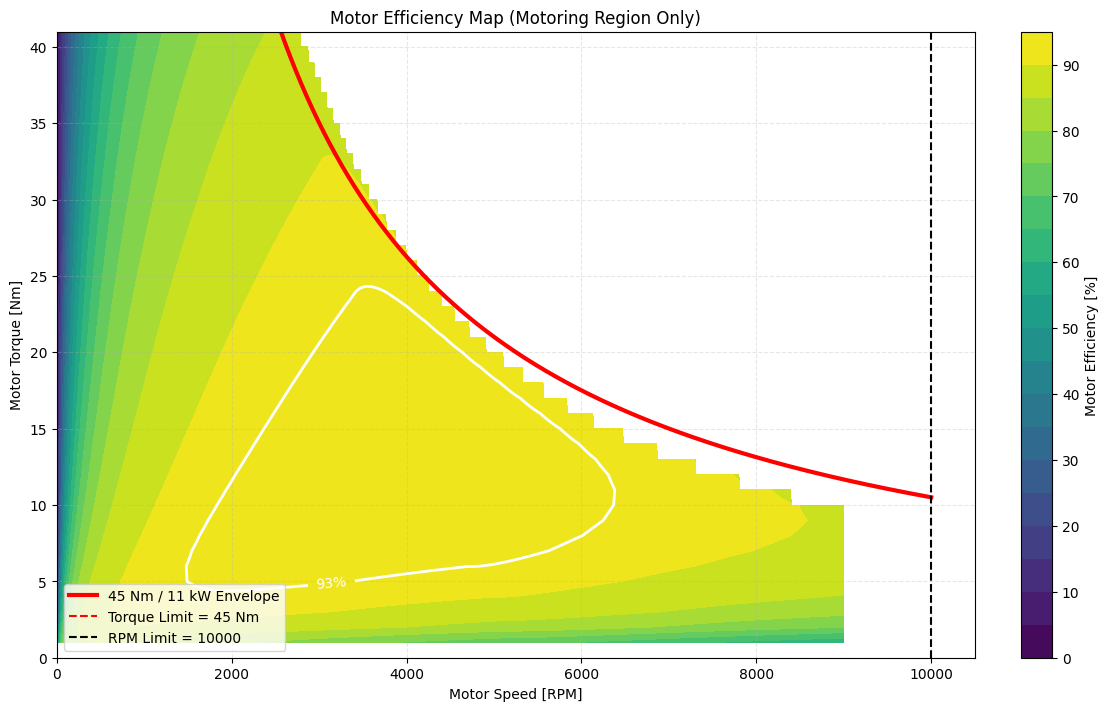

Maximum efficiency               : 94.13%
Maximum-efficiency point         : 4260 rpm, 13.0 Nm
High-efficiency threshold        : 92.51%
45 Nm / 11 kW base speed         : 2334 rpm


In [11]:
# ==========================================================
# POSITIVE TORQUE (MOTORING) EFFICIENCY MAP ONLY
# ==========================================================

RPM_mesh, TORQUE_mesh = np.meshgrid(rpm_grid, torque_grid)

fig, ax = plt.subplots(
    figsize=(11, 7),
    constrained_layout=True
)

# ----------------------------------------------------------
# Efficiency map
# ----------------------------------------------------------

contour = ax.contourf(
    RPM_mesh,
    TORQUE_mesh,
    eff_map * 100.0,
    levels=20,
    cmap="viridis"
)

colorbar = fig.colorbar(contour, ax=ax)
colorbar.set_label("Motor Efficiency [%]")

# ----------------------------------------------------------
# High-efficiency region
# ----------------------------------------------------------

high_eff_threshold = max(
    0.85,
    float(np.nanpercentile(eff_map, 75))
)

high_eff_contour = ax.contour(
    RPM_mesh,
    TORQUE_mesh,
    eff_map * 100.0,
    levels=[high_eff_threshold * 100.0],
    colors="white",
    linewidths=2.0
)

ax.clabel(
    high_eff_contour,
    fmt=lambda level: f"{level:.0f}%"
)

# ----------------------------------------------------------
# Torque speed envelope (45 Nm / 11 kW)
# ----------------------------------------------------------

peak_torque = 45.0      # Nm
peak_power_kw = 11.0    # kW

base_rpm = 9550 * peak_power_kw / peak_torque

rpm_curve = np.linspace(
    1,
    motor_max_rpm,
    2000
)

torque_envelope = np.where(
    rpm_curve <= base_rpm,
    peak_torque,
    9550 * peak_power_kw / rpm_curve
)

torque_envelope = np.minimum(
    torque_envelope,
    peak_torque
)

ax.plot(
    rpm_curve,
    torque_envelope,
    color="red",
    linewidth=3,
    label="45 Nm / 11 kW Envelope"
)

# Base speed point
ax.scatter(
    base_rpm,
    peak_torque,
    color="red",
    s=80,
    zorder=10
)

ax.annotate(
    f"Base RPM = {base_rpm:.0f}",
    xy=(base_rpm, peak_torque),
    xytext=(base_rpm + 400, peak_torque + 2),
    arrowprops=dict(arrowstyle="->")
)

# ----------------------------------------------------------
# Motor limits
# ----------------------------------------------------------

ax.axhline(
    motor_max_torque,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Torque Limit = {motor_max_torque:.0f} Nm"
)

ax.axvline(
    motor_max_rpm,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"RPM Limit = {motor_max_rpm:.0f}"
)

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------

ax.set_xlim(0, motor_max_rpm * 1.05)
ax.set_ylim(0, torque_grid.max())

ax.set_xlabel("Motor Speed [RPM]")
ax.set_ylabel("Motor Torque [Nm]")

ax.set_title(
    "Motor Efficiency Map (Motoring Region Only)"
)

ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(loc="best")

plt.show()

# ==========================================================
# Peak efficiency summary
# ==========================================================

max_eff_index = np.unravel_index(
    np.nanargmax(eff_map),
    eff_map.shape
)

max_eff_rpm = rpm_grid[max_eff_index[1]]
max_eff_torque = torque_grid[max_eff_index[0]]
max_eff = eff_map[max_eff_index]

print(f"Maximum efficiency               : {max_eff:.2%}")
print(f"Maximum-efficiency point         : {max_eff_rpm:.0f} rpm, {max_eff_torque:.1f} Nm")
print(f"High-efficiency threshold        : {high_eff_threshold:.2%}")
print(f"45 Nm / 11 kW base speed         : {base_rpm:.0f} rpm")

## 10. Build robust efficiency interpolators

In [12]:
linear_efficiency_interpolator = RegularGridInterpolator(
    (torque_grid, rpm_grid),
    eff_map,
    method="linear",
    bounds_error=False,
    fill_value=np.nan,
)

# Nearest-neighbour fallback is constructed only from measured/finite cells.
rpm_mesh, torque_mesh = np.meshgrid(rpm_grid, torque_grid)
finite_map_mask = np.isfinite(eff_map)

finite_points = np.column_stack([
    torque_mesh[finite_map_mask],
    rpm_mesh[finite_map_mask],
])
finite_efficiencies = eff_map[finite_map_mask]

if finite_efficiencies.size == 0:
    raise ValueError("No finite efficiency-map cells are available.")

nearest_efficiency_interpolator = NearestNDInterpolator(
    finite_points,
    finite_efficiencies,
)

map_has_negative_torque = torque_grid.min() < 0
map_uses_absolute_rpm = rpm_grid.min() >= 0

print("Map contains signed torque:", map_has_negative_torque)
print("Map uses nonnegative RPM:", map_uses_absolute_rpm)
print("Finite map cells:", finite_map_mask.sum())
print("Missing map cells:", (~finite_map_mask).sum())


Map contains signed torque: False
Map uses nonnegative RPM: True
Finite map cells: 23170
Missing map cells: 14672


In [13]:
def motor_efficiency(
    rpm,
    torque,
    mechanical_power,
    allow_boundary_clamping=True,
    allow_nearest_fallback=True,
):
    """Return efficiency and interpolation diagnostics for array operating points."""

    rpm = np.asarray(rpm, dtype=float)
    torque = np.asarray(torque, dtype=float)
    mechanical_power = np.asarray(mechanical_power, dtype=float)

    if not (rpm.shape == torque.shape == mechanical_power.shape):
        raise ValueError("RPM, torque, and mechanical power must have equal shapes.")

    rpm_query_original = np.abs(rpm) if map_uses_absolute_rpm else rpm.copy()
    torque_query_original = torque.copy() if map_has_negative_torque else np.abs(torque)

    active = np.abs(mechanical_power) > power_epsilon

    outside_original_map = active & (
        (rpm_query_original < rpm_grid.min())
        | (rpm_query_original > rpm_grid.max())
        | (torque_query_original < torque_grid.min())
        | (torque_query_original > torque_grid.max())
    )

    rpm_query = rpm_query_original.copy()
    torque_query = torque_query_original.copy()
    fallback_used = np.zeros(rpm.shape, dtype=bool)

    if allow_boundary_clamping:
        rpm_query = np.clip(rpm_query, rpm_grid.min(), rpm_grid.max())
        torque_query = np.clip(torque_query, torque_grid.min(), torque_grid.max())
        fallback_used |= outside_original_map

    query_points = np.column_stack([torque_query, rpm_query])
    efficiency = linear_efficiency_interpolator(query_points)

    # Linear interpolation becomes NaN around missing cells.
    linear_nan = active & ~np.isfinite(efficiency)

    if allow_nearest_fallback and np.any(linear_nan):
        efficiency[linear_nan] = nearest_efficiency_interpolator(
            torque_query[linear_nan],
            rpm_query[linear_nan],
        )
        fallback_used[linear_nan] = True

    # No conversion loss needs to be calculated when shaft power is zero.
    efficiency[~active] = 1.0

    final_invalid = active & (
        ~np.isfinite(efficiency)
        | (efficiency < minimum_efficiency)
        | (efficiency > 1.0)
    )
    efficiency[final_invalid] = np.nan

    return efficiency, fallback_used, outside_original_map


## 11. Evaluate motor efficiency at each ratio

In [14]:
eta_motor_g1, eta_fallback_g1, eta_outside_map_g1 = motor_efficiency(
    rpm_g1,
    torque_g1,
    motor_power_g1,
    allow_boundary_clamping=allow_boundary_clamping,
    allow_nearest_fallback=allow_nearest_fallback,
)

eta_motor_g2, eta_fallback_g2, eta_outside_map_g2 = motor_efficiency(
    rpm_g2,
    torque_g2,
    motor_power_g2,
    allow_boundary_clamping=allow_boundary_clamping,
    allow_nearest_fallback=allow_nearest_fallback,
)

active = np.abs(wheel_power) > power_epsilon

print("Gear 1 final active NaNs:", np.sum(active & ~np.isfinite(eta_motor_g1)))
print("Gear 2 final active NaNs:", np.sum(active & ~np.isfinite(eta_motor_g2)))
print("Gear 1 fallback points:", np.sum(active & eta_fallback_g1))
print("Gear 2 fallback points:", np.sum(active & eta_fallback_g2))
print("Gear 1 outside-map points:", np.sum(active & eta_outside_map_g1))
print("Gear 2 outside-map points:", np.sum(active & eta_outside_map_g2))

Gear 1 final active NaNs: 0
Gear 2 final active NaNs: 0
Gear 1 fallback points: 2385
Gear 2 fallback points: 1358
Gear 1 outside-map points: 0
Gear 2 outside-map points: 0


## 12. Selected operating points on the signed efficiency map

Interpretation of the colors and symbols:

- Background color: efficiency from the supplied map. The lower half is a mirror of the positive-torque map because no separate regenerative map was supplied.
- Black points: selected operating points from the hysteresis controller.
- Green arrows: actual Gear 1 to Gear 2 upshifts.
- Orange arrows: actual Gear 2 to Gear 1 downshifts.
- Red dashed lines: motor torque limits. Black dashed line: motor speed limit.

The manager baseline for this notebook is an upshift at 32 km/h and a downshift at 22 km/h. The threshold-comparison panels and optimization section use the same 22 km/h downshift baseline unless they explicitly state that a threshold is being varied.

NameError: name 'SIGNED_RPM_mesh' is not defined

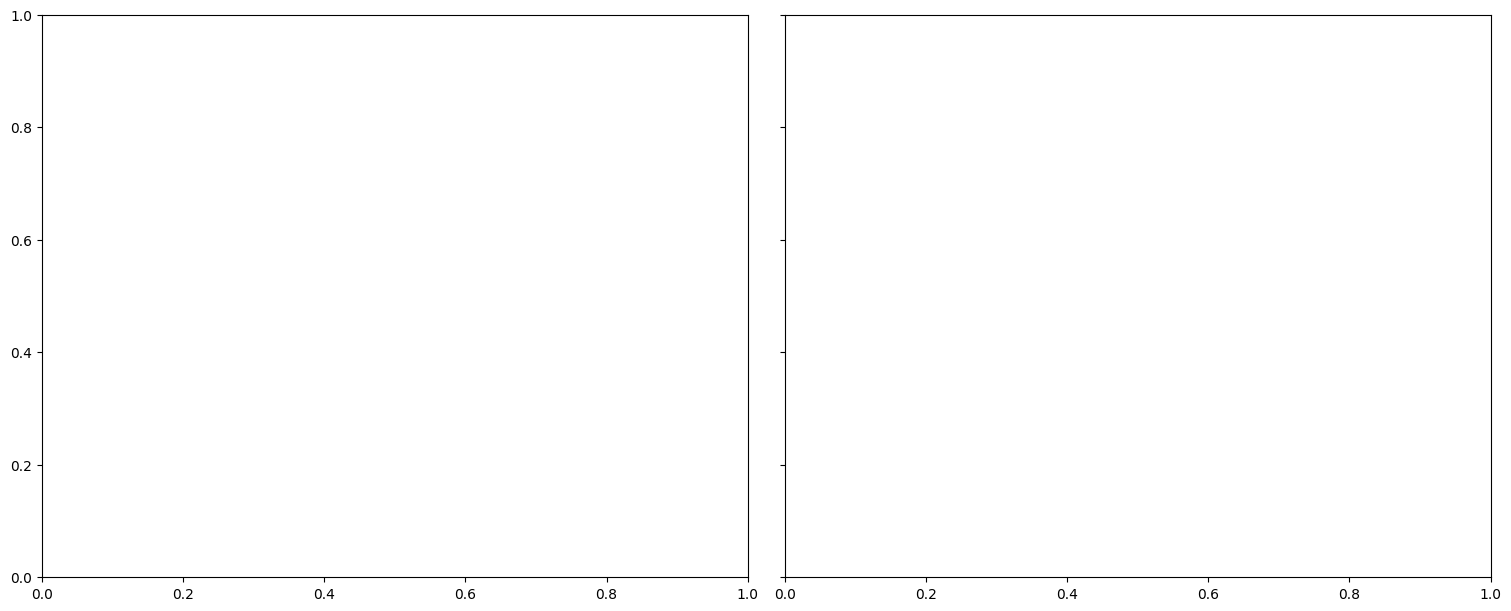

In [15]:
selected_eta = np.where(gear == 1, eta_motor_g1, eta_motor_g2)
selected_rpm_for_map = np.where(gear == 1, rpm_g1, rpm_g2)
selected_torque_for_map = np.where(gear == 1, torque_g1, torque_g2)
selected_map_mask = active_points & np.isfinite(selected_eta)

# Plot selected points on separate signed maps. No hypothetical ratio points are included.
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True, constrained_layout=True)
for axis, gear_mask, marker, title in [
    (axes[0], selected_gear1, "o", f"Selected Gear 1, ratio {G1:g}"),
    (axes[1], selected_gear2, "^", f"Selected Gear 2, ratio {G2:g}"),
]:
    gear_indices = np.flatnonzero(selected_map_mask & gear_mask)
    gear_indices = gear_indices[::max(1, int(np.ceil(len(gear_indices) / 4000)))]
    contour = axis.contourf(
        SIGNED_RPM_mesh,
        SIGNED_TORQUE_mesh,
        signed_eff_map * 100.0,
        levels=20,
        cmap="viridis",
        alpha=0.72,
    )
    axis.scatter(
        selected_rpm_for_map[gear_indices],
        selected_torque_for_map[gear_indices],
        c=speed_kmh[gear_indices],
        cmap="plasma",
        marker=marker,
        s=10,
        alpha=0.55,
    )
    axis.axhline(0.0, color="black", linewidth=0.8)
    axis.axhline(motor_max_torque, color="red", linestyle="--")
    axis.axhline(motor_min_torque, color="red", linestyle="--")
    axis.axvline(motor_max_rpm, color="black", linestyle="--")
    axis.set_title(title)
    axis.set_xlabel("Motor speed [RPM]")
    axis.grid(True, alpha=0.25)
axes[0].set_ylabel("Signed motor torque [Nm]\n(+ motoring, - regeneration)")
fig.colorbar(contour, ax=axes, label="Map efficiency [%]; lower half mirrored")
fig.suptitle(
    f"Selected operating points on signed efficiency map; upshift {upshift_speed:g} km/h, downshift {downshift_speed:g} km/h",
    fontweight="bold",
)
plt.show()

# Show a readable sample of actual transitions rather than drawing all 114 arrows.
actual_shift_indices = np.flatnonzero(np.diff(gear) != 0)
upshift_transition_indices = actual_shift_indices[gear[actual_shift_indices + 1] == 2]
downshift_transition_indices = actual_shift_indices[gear[actual_shift_indices + 1] == 1]
transition_indices_to_plot = np.unique(np.concatenate([
    upshift_transition_indices[::max(1, len(upshift_transition_indices) // 12)],
    downshift_transition_indices[::max(1, len(downshift_transition_indices) // 12)],
]))

fig_transition, ax_transition = plt.subplots(figsize=(11, 7), constrained_layout=True)
transition_contour = ax_transition.contourf(
    SIGNED_RPM_mesh,
    SIGNED_TORQUE_mesh,
    signed_eff_map * 100.0,
    levels=20,
    cmap="viridis",
    alpha=0.62,
)
for index in transition_indices_to_plot:
    before = index
    after = index + 1
    is_upshift = gear[after] == 2
    ax_transition.annotate(
        "",
        xy=(selected_rpm_for_map[after], selected_torque_for_map[after]),
        xytext=(selected_rpm_for_map[before], selected_torque_for_map[before]),
        arrowprops={
            "arrowstyle": "->",
            "color": "lime" if is_upshift else "orange",
            "alpha": 0.85,
            "linewidth": 1.0,
        },
    )
    ax_transition.text(
        selected_rpm_for_map[after],
        selected_torque_for_map[after],
        f"{speed_kmh[after]:.0f}",
        fontsize=7,
        color="white",
    )
ax_transition.scatter([], [], color="lime", label="Upshift: Gear 1 -> Gear 2")
ax_transition.scatter([], [], color="orange", label="Downshift: Gear 2 -> Gear 1")
ax_transition.axhline(0.0, color="black", linewidth=0.8)
ax_transition.axhline(motor_max_torque, color="red", linestyle="--", label="Torque limits")
ax_transition.axhline(motor_min_torque, color="red", linestyle="--")
ax_transition.axvline(motor_max_rpm, color="black", linestyle="--", label="RPM limit")
ax_transition.set_xlabel("Motor speed [RPM]")
ax_transition.set_ylabel("Signed motor torque [Nm]\n(+ motoring, - regeneration)")
ax_transition.set_title(
    f"Actual gear-transition movement; {len(upshift_transition_indices)} upshifts, {len(downshift_transition_indices)} downshifts\n"
    f"Thresholds: upshift {upshift_speed:g} km/h, downshift {downshift_speed:g} km/h; labels show vehicle speed [km/h]"
)
ax_transition.grid(True, alpha=0.25)
ax_transition.legend()
fig_transition.colorbar(transition_contour, ax=ax_transition, label="Map efficiency [%]; lower half mirrored")
plt.show()

shift_events_df = pd.DataFrame({
    "Time [s]": time[actual_shift_indices + 1],
    "Vehicle speed [km/h]": speed_kmh[actual_shift_indices + 1],
    "Shift": np.where(gear[actual_shift_indices + 1] == 2, "Upshift 1->2", "Downshift 2->1"),
    "Motor RPM before": selected_rpm_for_map[actual_shift_indices],
    "Motor RPM after": selected_rpm_for_map[actual_shift_indices + 1],
    "Motor torque before [Nm]": selected_torque_for_map[actual_shift_indices],
    "Motor torque after [Nm]": selected_torque_for_map[actual_shift_indices + 1],
})
display(shift_events_df.head(12))
print(f"Actual shifts: {len(actual_shift_indices)} ({len(upshift_transition_indices)} upshifts, {len(downshift_transition_indices)} downshifts)")
print("Negative-torque map values use the mirrored positive-torque efficiency assumption.")

## 13. Compare selected torque-speed paths on the motor efficiency map

This comparison reruns the same hysteresis controller for upshift thresholds of 20, 25, 30, 32, 35, and 40 km/h. The downshift threshold is fixed at the manager baseline of 22 km/h.

Every panel uses the same signed efficiency-map background and high-efficiency boundary:

- Horizontal axis: motor mechanical speed in RPM.
- Vertical axis: signed motor torque in Nm. Positive torque is motoring; negative torque is regeneration.
- Background color: motor efficiency percentage. The negative-torque half is mirrored from the supplied positive-torque map because no separate regenerative map was provided.
- Thick white contour: high-efficiency zone boundary, using the same threshold shown in the map-analysis section.
- Blue circles: selected Gear 1 points.
- Purple triangles: selected Gear 2 points.
- Green arrows: actual Gear 1 to Gear 2 upshifts.
- Orange arrows: actual Gear 2 to Gear 1 downshifts.
- Arrow labels: vehicle speed at the shift, written explicitly as `Shift speed = XX km/h`.
- Red dashed lines: motor torque limits. Black dashed line: motor RPM limit.

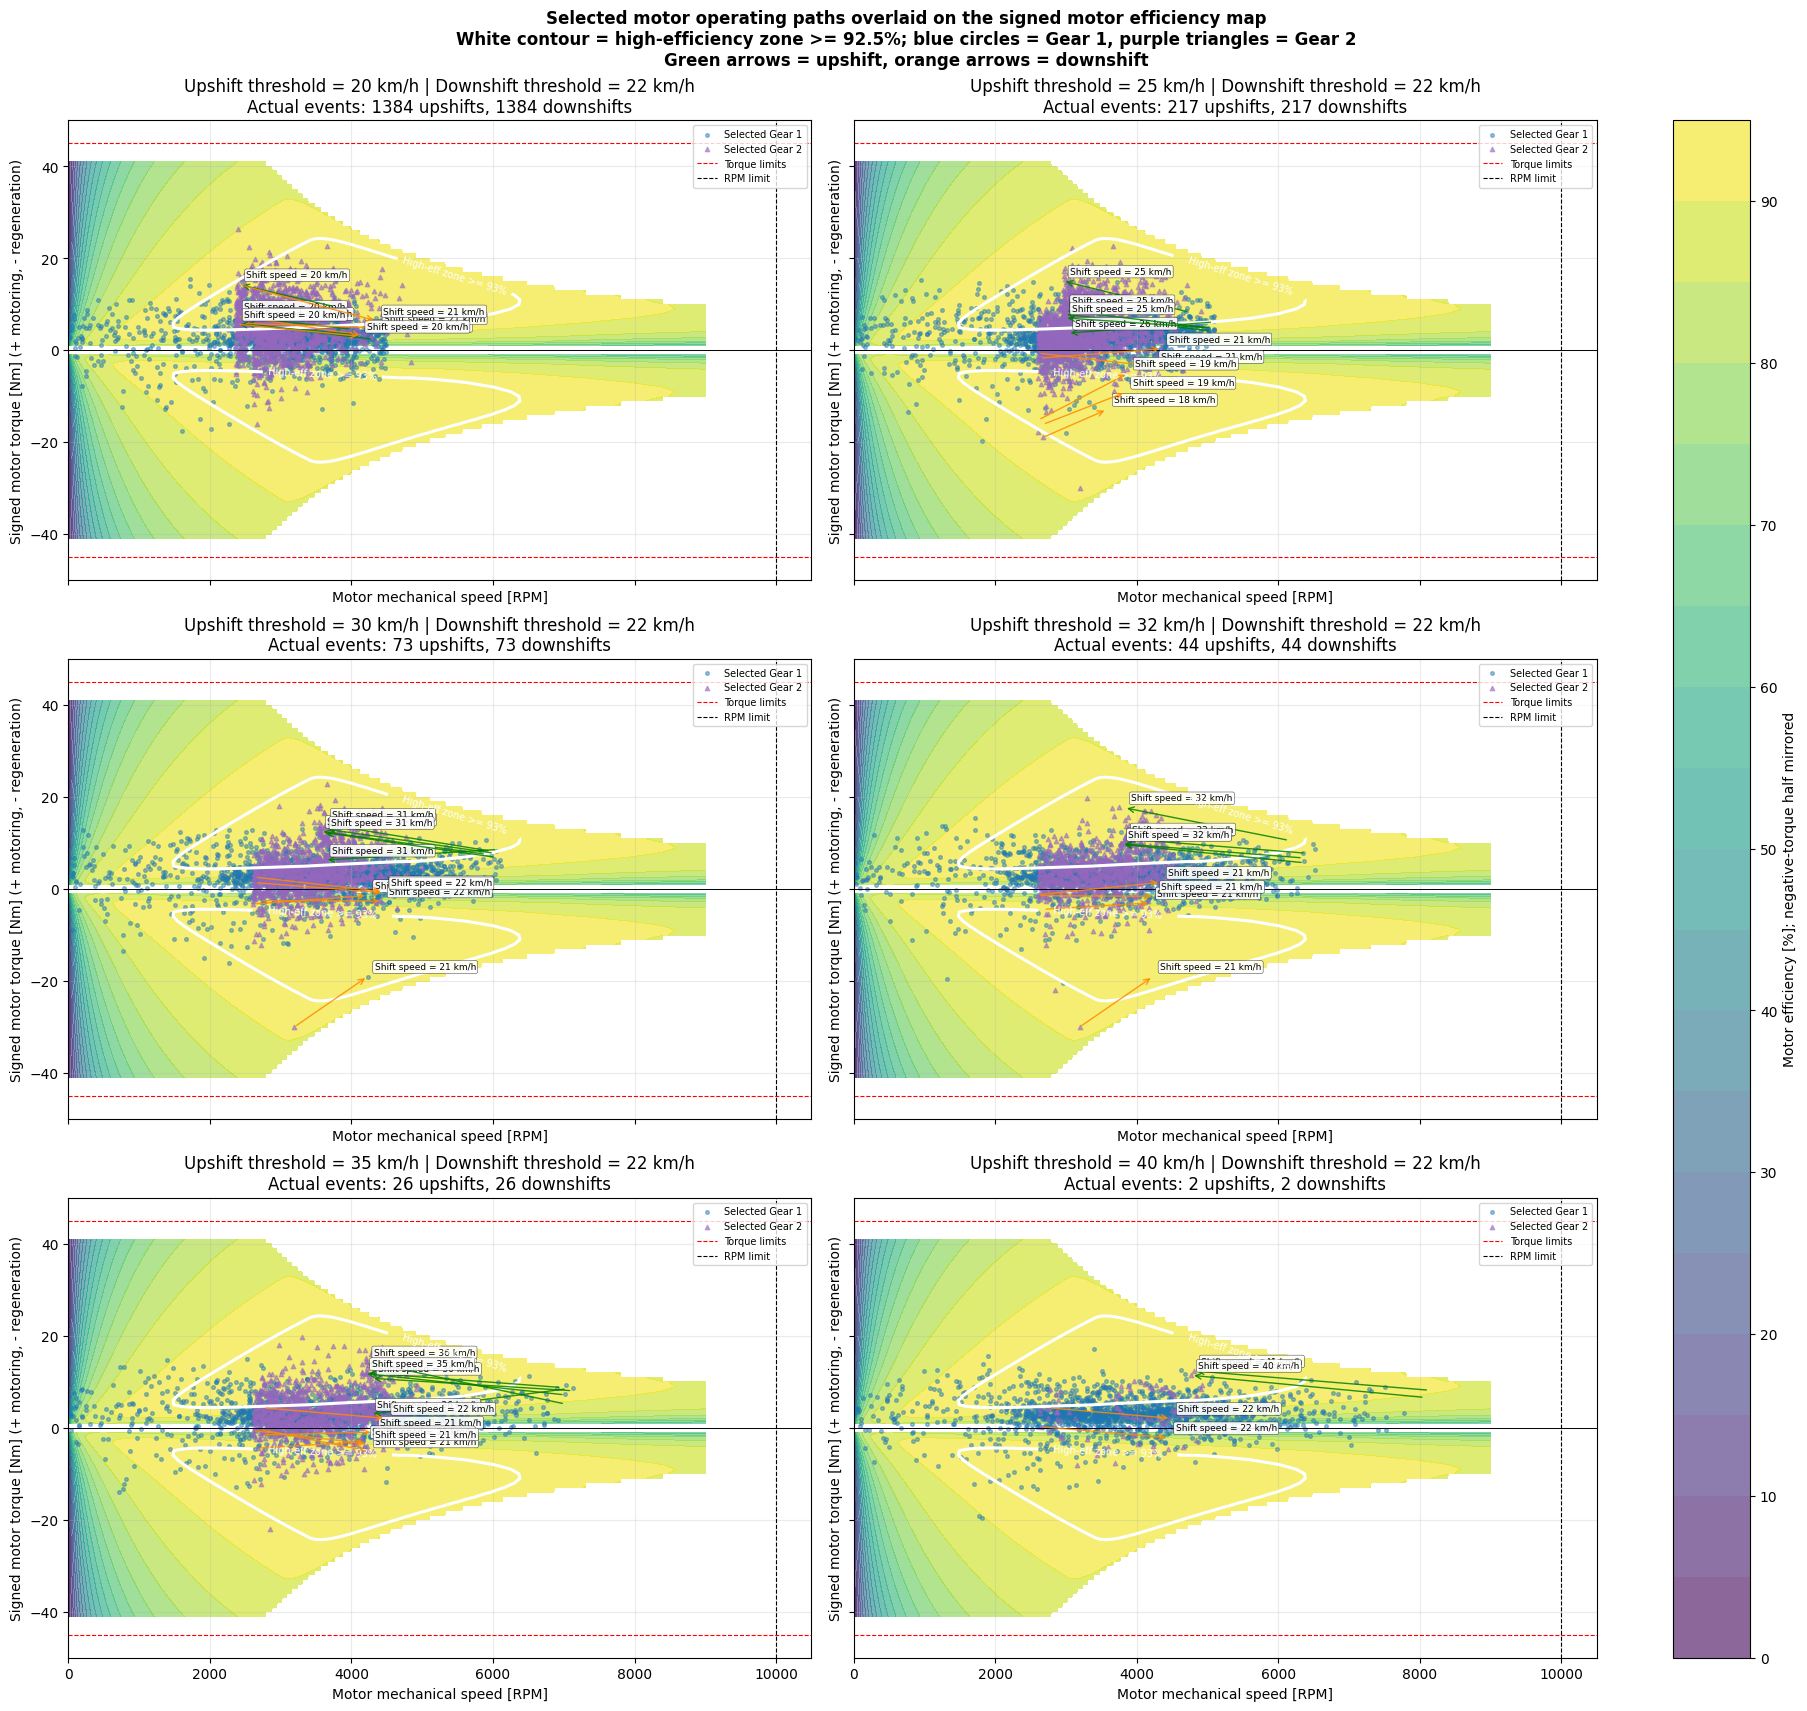

,Upshift [km/h],Downshift [km/h],Upshifts,Downshifts,Gear 1 active points,Gear 2 active points,Consumed input energy [kWh]
0,20.0,22.0,1384,1384,14507,7260,8.642576
1,25.0,22.0,217,217,17379,4388,8.679481
2,30.0,22.0,73,73,19388,2379,8.714829
3,32.0,22.0,44,44,19944,1823,8.728172
4,35.0,22.0,26,26,20645,1122,8.751715
5,40.0,22.0,2,2,21678,89,8.786447


X-axis: motor mechanical speed in RPM.
Y-axis: signed motor torque in Nm; positive means motoring and negative means regeneration.
White contour: operating region with map efficiency >= 92.51%.
Arrow label: vehicle speed at the actual gear change, shown as Shift speed = XX km/h.
All comparison panels use the same downshift threshold of 22 km/h.


In [ ]:
comparison_upshift_speeds = [20.0, 25.0, 30.0, 32.0, 35.0, 40.0]
comparison_results = {}
comparison_rows = []

for comparison_upshift_speed in comparison_upshift_speeds:
    comparison_results[comparison_upshift_speed] = calculate_cycle_energy_for_shift(
        comparison_upshift_speed,
        downshift_speed,
    )

fig, comparison_axes = plt.subplots(3, 2, figsize=(18, 17), sharex=True, sharey=True, constrained_layout=True)
comparison_axes = comparison_axes.ravel()

for panel_index, comparison_upshift_speed in enumerate(comparison_upshift_speeds):
    comparison_result = comparison_results[comparison_upshift_speed]
    comparison_gear = comparison_result["gear"]
    comparison_rpm = comparison_result["selected_motor_rpm"]
    comparison_torque = comparison_result["selected_motor_torque"]
    comparison_active = np.abs(wheel_power) > power_epsilon
    comparison_gear1 = comparison_active & (comparison_gear == 1)
    comparison_gear2 = comparison_active & (comparison_gear == 2)
    comparison_shift_indices = np.flatnonzero(np.diff(comparison_gear) != 0)
    comparison_upshifts = comparison_shift_indices[comparison_gear[comparison_shift_indices + 1] == 2]
    comparison_downshifts = comparison_shift_indices[comparison_gear[comparison_shift_indices + 1] == 1]

    axis = comparison_axes[panel_index]
    background_contour = axis.contourf(SIGNED_RPM_mesh, SIGNED_TORQUE_mesh, signed_eff_map * 100.0, levels=20, cmap="viridis", alpha=0.62)
    high_zone_contour = axis.contour(SIGNED_RPM_mesh, SIGNED_TORQUE_mesh, signed_eff_map * 100.0, levels=[high_eff_threshold * 100.0], colors="white", linewidths=2.2)
    axis.clabel(high_zone_contour, fmt=lambda level: f"High-eff zone >= {level:.0f}%", fontsize=7, inline=True)

    gear1_indices = np.flatnonzero(comparison_gear1)[::max(1, int(np.ceil(np.sum(comparison_gear1) / 1800)))]
    gear2_indices = np.flatnonzero(comparison_gear2)[::max(1, int(np.ceil(np.sum(comparison_gear2) / 1800)))]
    axis.scatter(comparison_rpm[gear1_indices], comparison_torque[gear1_indices], color="tab:blue", marker="o", s=7, alpha=0.45, label="Selected Gear 1")
    axis.scatter(comparison_rpm[gear2_indices], comparison_torque[gear2_indices], color="tab:purple", marker="^", s=10, alpha=0.55, label="Selected Gear 2")

    transition_subset = np.unique(np.concatenate([
        comparison_upshifts[::max(1, len(comparison_upshifts) // 4)],
        comparison_downshifts[::max(1, len(comparison_downshifts) // 4)],
    ]))
    for shift_index in transition_subset:
        before = shift_index
        after = shift_index + 1
        is_upshift = comparison_gear[after] == 2
        axis.annotate("", xy=(comparison_rpm[after], comparison_torque[after]), xytext=(comparison_rpm[before], comparison_torque[before]), arrowprops={"arrowstyle": "->", "color": "green" if is_upshift else "darkorange", "linewidth": 1.0, "alpha": 0.85})
        axis.annotate(f"Shift speed = {speed_kmh[after]:.0f} km/h", xy=(comparison_rpm[after], comparison_torque[after]), xytext=(5, 5), textcoords="offset points", fontsize=6.5, color="black", bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "edgecolor": "black", "linewidth": 0.3, "alpha": 0.9})

    axis.axhline(0.0, color="black", linewidth=0.7)
    axis.axhline(motor_max_torque, color="red", linestyle="--", linewidth=0.8, label="Torque limits")
    axis.axhline(motor_min_torque, color="red", linestyle="--", linewidth=0.8)
    axis.axvline(motor_max_rpm, color="black", linestyle="--", linewidth=0.8, label="RPM limit")
    axis.set_title(f"Upshift threshold = {comparison_upshift_speed:g} km/h | Downshift threshold = {downshift_speed:g} km/h\nActual events: {len(comparison_upshifts)} upshifts, {len(comparison_downshifts)} downshifts")
    axis.grid(True, alpha=0.25)
    axis.set_xlim(left=0)
    axis.set_ylim(motor_min_torque - 5, motor_max_torque + 5)
    axis.legend(fontsize=7, loc="upper right")

    comparison_rows.append({
        "Upshift [km/h]": comparison_upshift_speed,
        "Downshift [km/h]": downshift_speed,
        "Upshifts": len(comparison_upshifts),
        "Downshifts": len(comparison_downshifts),
        "Gear 1 active points": int(np.sum(comparison_gear1)),
        "Gear 2 active points": int(np.sum(comparison_gear2)),
        "Consumed input energy [kWh]": comparison_result["consumed_energy_kwh"],
    })

for axis in comparison_axes:
    axis.set_xlabel("Motor mechanical speed [RPM]")
    axis.set_ylabel("Signed motor torque [Nm] (+ motoring, - regeneration)")
fig.colorbar(background_contour, ax=comparison_axes, label="Motor efficiency [%]; negative-torque half mirrored")
fig.suptitle("Selected motor operating paths overlaid on the signed motor efficiency map\n" f"White contour = high-efficiency zone >= {high_eff_threshold:.1%}; blue circles = Gear 1, purple triangles = Gear 2\n" "Green arrows = upshift, orange arrows = downshift", fontweight="bold")
plt.show()

comparison_summary_df = pd.DataFrame(comparison_rows)
display(comparison_summary_df)
print("X-axis: motor mechanical speed in RPM.")
print("Y-axis: signed motor torque in Nm; positive means motoring and negative means regeneration.")
print(f"White contour: operating region with map efficiency >= {high_eff_threshold:.2%}.")
print("Arrow label: vehicle speed at the actual gear change, shown as Shift speed = XX km/h.")
print(f"All comparison panels use the same downshift threshold of {downshift_speed:g} km/h.")

## 13. Cycle-energy calculation for one shift-speed variant

In [ ]:
def calculate_cycle_energy_for_shift(
    upshift_speed_kmh,
    downshift_speed_kmh=22.0,
):
    gear = np.ones_like(speed_kmh, dtype=int)
    current_gear = 1

    for index in range(len(speed_kmh)):
        if current_gear == 1 and speed_kmh[index] >= upshift_speed_kmh:
            current_gear = 2
        elif current_gear == 2 and speed_kmh[index] <= downshift_speed_kmh:
            current_gear = 1
        gear[index] = current_gear

    use_g1 = gear == 1
    motor_rpm = np.where(use_g1, rpm_g1, rpm_g2)
    motor_torque = np.where(use_g1, torque_g1, torque_g2)
    motor_eta = np.where(use_g1, eta_motor_g1, eta_motor_g2)
    gearbox_eta = np.where(use_g1, eta_gear_1, eta_gear_2)
    efficiency_fallback = np.where(use_g1, eta_fallback_g1, eta_fallback_g2)
    outside_original_map = np.where(use_g1, eta_outside_map_g1, eta_outside_map_g2)

    active_local = np.abs(wheel_power) > power_epsilon

    rpm_ok = np.abs(motor_rpm) <= motor_max_rpm
    torque_ok = (
        (motor_torque <= motor_max_torque)
        & (motor_torque >= motor_min_torque)
    )
    motor_limit_ok = rpm_ok & torque_ok

    efficiency_ok = (
        np.isfinite(motor_eta)
        & (motor_eta >= minimum_efficiency)
        & (motor_eta <= 1.0)
    )

    operating_point_ok = ~active_local | (motor_limit_ok & efficiency_ok)

    battery_power = np.zeros_like(wheel_power, dtype=float)
    motoring = wheel_power > power_epsilon
    regen = wheel_power < -power_epsilon

    valid_motoring = motoring & motor_limit_ok & efficiency_ok
    valid_regen = regen & motor_limit_ok & efficiency_ok

    battery_power[valid_motoring] = (
        wheel_power[valid_motoring]
        / (motor_eta[valid_motoring] * gearbox_eta[valid_motoring])
    )
    battery_power[valid_regen] = (
        wheel_power[valid_regen]
        * motor_eta[valid_regen]
        * gearbox_eta[valid_regen]
    )

    invalid_active = active_local & ~operating_point_ok
    battery_power[invalid_active] = np.nan

    battery_power_ok = (
        np.isfinite(battery_power)
        & (np.abs(battery_power) <= battery_max_power)
    )
    point_valid = operating_point_ok & battery_power_ok
    cycle_valid = bool(np.all(point_valid))

    if cycle_valid:
        net_energy_kwh = np.trapezoid(battery_power, time) / 3.6e6
        consumed_energy_kwh = (
            np.trapezoid(np.maximum(battery_power, 0.0), time) / 3.6e6
        )
        recovered_energy_kwh = (
            -np.trapezoid(np.minimum(battery_power, 0.0), time) / 3.6e6
        )
    else:
        net_energy_kwh = np.nan
        consumed_energy_kwh = np.nan
        recovered_energy_kwh = np.nan

    finite_battery_power = battery_power[np.isfinite(battery_power)]
    max_battery_power_kw = (
        finite_battery_power.max() / 1000.0
        if finite_battery_power.size else np.nan
    )
    min_battery_power_kw = (
        finite_battery_power.min() / 1000.0
        if finite_battery_power.size else np.nan
    )

    shift_idx = np.flatnonzero(np.diff(gear) != 0)
    upshift_count = int(np.sum(gear[shift_idx + 1] == 2))
    downshift_count = int(np.sum(gear[shift_idx + 1] == 1))

    return {
        "shift_speed_kmh": float(upshift_speed_kmh),
        "downshift_speed_kmh": float(downshift_speed_kmh),
        "net_energy_kwh": net_energy_kwh,
        "consumed_energy_kwh": consumed_energy_kwh,
        "recovered_energy_kwh": recovered_energy_kwh,
        "valid": cycle_valid,
        "invalid_points": int(np.sum(~point_valid)),
        "remaining_map_invalid_points": int(np.sum(active_local & ~efficiency_ok)),
        "efficiency_fallback_points": int(np.sum(active_local & efficiency_fallback)),
        "outside_original_map_points": int(np.sum(active_local & outside_original_map)),
        "motor_limit_points": int(np.sum(active_local & ~motor_limit_ok)),
        "battery_limit_points": int(np.sum(
            np.isfinite(battery_power)
            & (np.abs(battery_power) > battery_max_power)
        )),
        "maximum_battery_power_kw": max_battery_power_kw,
        "minimum_battery_power_kw": min_battery_power_kw,
        "upshift_events": upshift_count,
        "downshift_events": downshift_count,
        "battery_power": battery_power,
        "point_valid": point_valid,
        "gear": gear,
        "use_g1": use_g1,
        "selected_motor_rpm": motor_rpm,
        "selected_motor_torque": motor_torque,
        "selected_motor_efficiency": motor_eta,
    }

## 14. First optimization: upshift speed with downshift fixed at 22 km/h

In [ ]:
# First optimization: vary upshift speed while keeping the manager downshift at 22 km/h.
downshift_speed_for_sweep = 22.0
shift_speeds = np.arange(20.0, 43.0, 1.0)

sweep_details = [
    calculate_cycle_energy_for_shift(
        upshift_speed_kmh=shift_speed,
        downshift_speed_kmh=downshift_speed_for_sweep,
    )
    for shift_speed in shift_speeds
]

array_keys = {
    "battery_power",
    "point_valid",
    "gear",
    "use_g1",
    "selected_motor_rpm",
    "selected_motor_torque",
    "selected_motor_efficiency",
}

results_df = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key not in array_keys
    }
    for result in sweep_details
])

results_df = results_df.rename(columns={
    "shift_speed_kmh": "Upshift Speed [km/h]",
    "downshift_speed_kmh": "Downshift Speed [km/h]",
    "net_energy_kwh": "Net Energy [kWh]",
    "consumed_energy_kwh": "Consumed Energy [kWh]",
    "recovered_energy_kwh": "Recovered Energy [kWh]",
    "valid": "Valid",
    "invalid_points": "Invalid Points",
    "remaining_map_invalid_points": "Map Invalid Points",
    "efficiency_fallback_points": "Fallback Points",
    "outside_original_map_points": "Outside Map Points",
    "motor_limit_points": "Motor Limit Points",
    "battery_limit_points": "Battery Limit Points",
    "maximum_battery_power_kw": "Max Battery Power [kW]",
    "minimum_battery_power_kw": "Min Battery Power [kW]",
    "upshift_events": "Upshift Events",
    "downshift_events": "Downshift Events",
})

display(results_df)

,Upshift Speed [km/h],Downshift Speed [km/h],Net Energy [kWh],Consumed Energy [kWh],Recovered Energy [kWh],Valid,Invalid Points,Map Invalid Points,Fallback Points,Outside Map Points,Motor Limit Points,Battery Limit Points,Max Battery Power [kW],Min Battery Power [kW],Upshift Events,Downshift Events
0,20.0,22.0,7.858680,8.642576,0.783895,True,0,0,1973,0,0,0,9.407977,-9.116190,1384,1384
1,21.0,22.0,7.866048,8.649100,0.783052,True,0,0,2000,0,0,0,9.407977,-9.116190,731,731
2,22.0,22.0,7.872248,8.655142,0.782893,True,0,0,2018,0,0,0,9.407977,-9.116190,355,355
3,23.0,22.0,7.880347,8.663112,0.782765,True,0,0,2023,0,0,0,9.407977,-9.116190,294,294
4,24.0,22.0,7.889248,8.671719,0.782470,True,0,0,2037,0,0,0,9.407977,-9.116190,257,257
5,25.0,22.0,7.897681,8.679481,0.781800,True,0,0,2054,0,0,0,9.407977,-9.116190,217,217
6,26.0,22.0,7.907153,8.687921,0.780769,True,0,0,2072,0,0,0,9.407977,-9.116190,174,174
7,27.0,22.0,7.915375,8.695211,0.779836,True,0,0,2096,0,0,0,9.407977,-9.116190,145,145
8,28.0,22.0,7.925184,8.703428,0.778244,True,0,0,2132,0,0,0,9.407977,-9.116190,114,114
9,29.0,22.0,7.931958,8.709077,0.777119,True,0,0,2157,0,0,0,9.407977,-9.116190,97,97


## 15. Manual verification of representative sweep points

These checks independently verify the gear sequence, transition counts, and energy identity for low, middle, and high upshift thresholds. Regeneration remains available in the internal calculation for validation, but it is excluded from the sweep plot and optimization criterion.

In [ ]:
verification_speeds = [20.0, 32.0, 49.0]
verification_rows = []

for verification_speed in verification_speeds:
    result = calculate_cycle_energy_for_shift(
        verification_speed,
        downshift_speed_for_sweep,
    )
    gear_changes = np.flatnonzero(np.diff(result["gear"]) != 0)
    expected_upshifts = int(np.sum(result["gear"][gear_changes + 1] == 2))
    expected_downshifts = int(np.sum(result["gear"][gear_changes + 1] == 1))
    manual_net = np.trapezoid(result["battery_power"], time) / 3.6e6
    manual_consumed = np.trapezoid(np.maximum(result["battery_power"], 0.0), time) / 3.6e6
    manual_recovered = -np.trapezoid(np.minimum(result["battery_power"], 0.0), time) / 3.6e6

    assert result["valid"]
    assert expected_upshifts == result["upshift_events"]
    assert expected_downshifts == result["downshift_events"]
    assert np.isclose(manual_net, result["net_energy_kwh"])
    assert np.isclose(manual_consumed, result["consumed_energy_kwh"])
    assert np.isclose(manual_recovered, result["recovered_energy_kwh"])
    assert np.isclose(manual_consumed - manual_recovered, manual_net)

    verification_rows.append({
        "Upshift [km/h]": verification_speed,
        "Downshift [km/h]": downshift_speed_for_sweep,
        "Gear changes": len(gear_changes),
        "Upshifts": result["upshift_events"],
        "Downshifts": result["downshift_events"],
        "Net energy [kWh]": result["net_energy_kwh"],
        "Consumed - recovered [kWh]": manual_consumed - manual_recovered,
        "Max |battery power| [kW]": np.max(np.abs(result["battery_power"])) / 1000.0,
    })

verification_df = pd.DataFrame(verification_rows)
display(verification_df)
print("Manual verification passed for 20/22, 32/22, and 49/22 representative cases.")

,Upshift [km/h],Downshift [km/h],Gear changes,Upshifts,Downshifts,Net energy [kWh],Consumed - recovered [kWh],Max |battery power| [kW]
0,20.0,22.0,2768,1384,1384,7.858680,7.858680,9.407977
1,32.0,22.0,88,44,44,7.955136,7.955136,9.471242
2,49.0,22.0,0,0,0,8.022396,8.022396,9.471242


Manual verification passed for 20/22, 32/22, and 49/22 representative cases.


### Motor input-side energy without regeneration

This sweep shows only positive motor input energy. Regenerated energy is excluded so the effect of the upshift threshold is easy to interpret.

The curve is piecewise because the drive cycle is sampled at discrete speeds. Several neighboring thresholds select exactly the same Gear 1/Gear 2 sequence, so they must have identical energy. A jump occurs only when a threshold changes the gear selected at one or more samples. The diagnostic table below identifies those ranges explicitly.

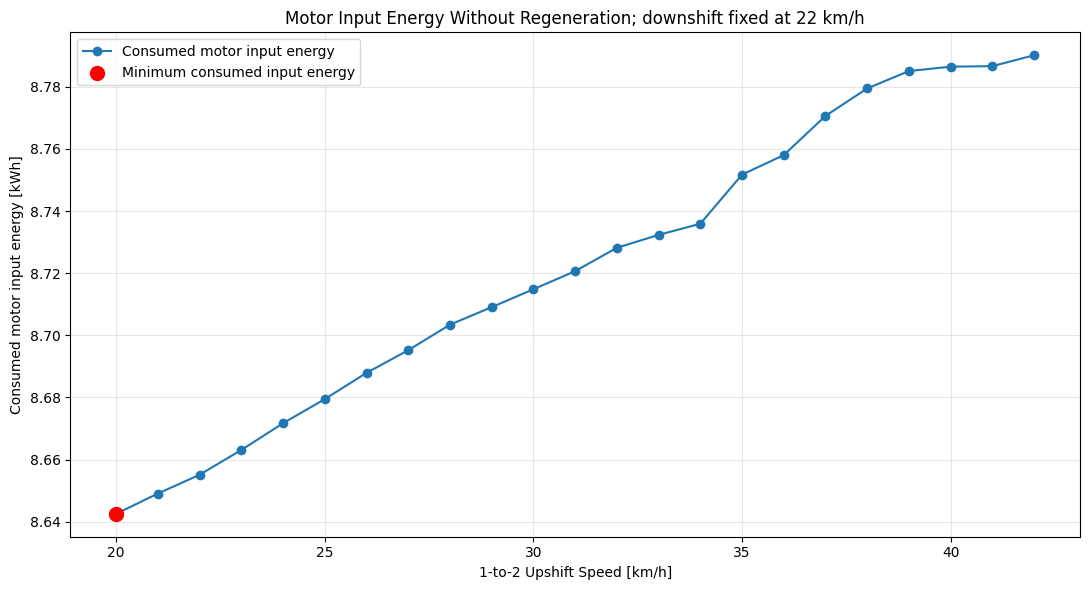

,Upshift range [km/h],Gear 2 samples,Upshift times [s],Downshift times [s],Consumed input energy [kWh]
0,20-20,7266,"137, 139, 141, 143, 145, 179, 181, 183, 224, 2...","138, 140, 142, 144, 146, 180, 182, 184, 225, 2...",8.642576
1,21-21,6646,"141, 144, 226, 228, 230, 683, 685, 718, 720, 7...","142, 145, 227, 229, 243, 684, 693, 719, 721, 7...",8.649100
2,22-22,6074,"230, 685, 864, 877, 885, 914, 1309, 1620, 1656...","243, 693, 865, 882, 902, 918, 1316, 1632, 1664...",8.655142
3,23-23,5488,"233, 689, 888, 916, 1313, 1620, 1657, 1704, 17...","243, 693, 902, 918, 1316, 1632, 1664, 1708, 17...",8.663112
4,24-24,4910,"235, 892, 1621, 1657, 1704, 1715, 2005, 2303, ...","243, 902, 1632, 1664, 1708, 1723, 2010, 2307, ...",8.671719
5,25-25,4393,"239, 893, 1626, 1658, 1705, 1715, 2317, 2347, ...","243, 902, 1632, 1664, 1708, 1723, 2326, 2352, ...",8.679481
6,26-26,3891,"894, 1658, 1716, 2317, 2348, 2398, 2407, 2503,...","902, 1664, 1723, 2326, 2352, 2401, 2423, 2505,...",8.687921
7,27-27,3479,"894, 1658, 1716, 2318, 2408, 2597, 2607, 3010,...","902, 1664, 1723, 2326, 2423, 2604, 2612, 3055,...",8.695211
8,28-28,3021,"896, 1659, 2318, 2408, 3010, 3448, 3495, 3884,...","902, 1664, 2326, 2423, 3055, 3479, 3511, 3905,...",8.703428
9,29-29,2715,"897, 2319, 2409, 3020, 3449, 3496, 3885, 3980,...","902, 2326, 2423, 3055, 3479, 3511, 3905, 3998,...",8.709077


Minimum consumed input energy: 8.642576 kWh
Consumed-energy range: 8.642576 to 8.790123 kWh


In [ ]:
valid_results = results_df.loc[results_df["Valid"]].copy()

if valid_results.empty:
    raise ValueError("No valid shift-speed variant is available for plotting.")

best_index_for_plot = valid_results["Consumed Energy [kWh]"].idxmin()
best_row_for_plot = valid_results.loc[best_index_for_plot]
consumed_energy = results_df["Consumed Energy [kWh]"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(
    results_df["Upshift Speed [km/h]"],
    consumed_energy,
    marker="o",
    color="tab:blue",
    label="Consumed motor input energy",
)
ax.scatter(
    best_row_for_plot["Upshift Speed [km/h]"],
    best_row_for_plot["Consumed Energy [kWh]"],
    color="red",
    s=100,
    zorder=3,
    label="Minimum consumed input energy",
)
ax.set_xlabel("1-to-2 Upshift Speed [km/h]")
ax.set_ylabel("Consumed motor input energy [kWh]")
ax.set_title(f"Motor Input Energy Without Regeneration; downshift fixed at {downshift_speed_for_sweep:g} km/h")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Group thresholds that produce the exact same sampled gear sequence.
pattern_groups = []
start_index = 0
for index in range(1, len(sweep_details) + 1):
    pattern_changed = (
        index == len(sweep_details)
        or not np.array_equal(
            sweep_details[index]["gear"],
            sweep_details[start_index]["gear"],
        )
    )
    if pattern_changed:
        group_speeds = shift_speeds[start_index:index]
        representative = sweep_details[start_index]
        representative_changes = np.flatnonzero(np.diff(representative["gear"]) != 0)
        representative_upshifts = representative_changes[representative["gear"][representative_changes + 1] == 2]
        representative_downshifts = representative_changes[representative["gear"][representative_changes + 1] == 1]
        pattern_groups.append({
            "Upshift range [km/h]": f"{group_speeds[0]:g}-{group_speeds[-1]:g}",
            "Gear 2 samples": int(np.sum(representative["gear"] == 2)),
            "Upshift times [s]": ", ".join(f"{time[item + 1]:g}" for item in representative_upshifts) or "None",
            "Downshift times [s]": ", ".join(f"{time[item + 1]:g}" for item in representative_downshifts) or "None",
            "Consumed input energy [kWh]": representative["consumed_energy_kwh"],
        })
        start_index = index

pattern_groups_df = pd.DataFrame(pattern_groups)
display(pattern_groups_df)

print(f"Minimum consumed input energy: {best_row_for_plot['Consumed Energy [kWh]']:.6f} kWh")
print(f"Consumed-energy range: {consumed_energy.min():.6f} to {consumed_energy.max():.6f} kWh")

In [ ]:
valid_results = results_df.loc[results_df["Valid"]].copy()

if valid_results.empty:
    print("No valid shift speed was found.")
    display(results_df[[
        "Upshift Speed [km/h]",
        "Downshift Speed [km/h]",
        "Invalid Points",
        "Map Invalid Points",
        "Fallback Points",
        "Outside Map Points",
        "Motor Limit Points",
        "Battery Limit Points",
    ]])
else:
    best_index = valid_results["Consumed Energy [kWh]"].idxmin()
    best_row = valid_results.loc[best_index]
    best_shift_speed = float(best_row["Upshift Speed [km/h]"])

    print(f"Best upshift speed for consumed input energy: {best_shift_speed:.1f} km/h")
    print(f"Fixed downshift speed: {best_row['Downshift Speed [km/h]']:.1f} km/h")
    print(f"Consumed motor input energy: {best_row['Consumed Energy [kWh]']:.6f} kWh")
    print(f"Net battery energy, reported separately: {best_row['Net Energy [kWh]']:.6f} kWh")
    print(f"Recovered energy, reported separately: {best_row['Recovered Energy [kWh]']:.6f} kWh")
    print(f"Upshift events: {int(best_row['Upshift Events'])}")
    print(f"Downshift events: {int(best_row['Downshift Events'])}")
    print(f"Fallback points: {int(best_row['Fallback Points'])}")
    print(f"Outside-map points: {int(best_row['Outside Map Points'])}")

Best upshift speed for consumed input energy: 20.0 km/h
Fixed downshift speed: 22.0 km/h
Consumed motor input energy: 8.642576 kWh
Net battery energy, reported separately: 7.858680 kWh
Recovered energy, reported separately: 0.783895 kWh
Upshift events: 1384
Downshift events: 1384
Fallback points: 1973
Outside-map points: 0


## 16. Optimize upshift and downshift thresholds

The manager baseline is 32 km/h upshift and 22 km/h downshift. The objective is consumed motor input energy, excluding regeneration from the plotted optimization criterion.

Three cases are evaluated:

1. Upshift-only optimization with downshift fixed at 22 km/h.
2. Downshift-only optimization with upshift fixed at 32 km/h.
3. Combined grid optimization of both thresholds.

Every candidate must satisfy `downshift < upshift` so the controller retains a valid hysteresis band.

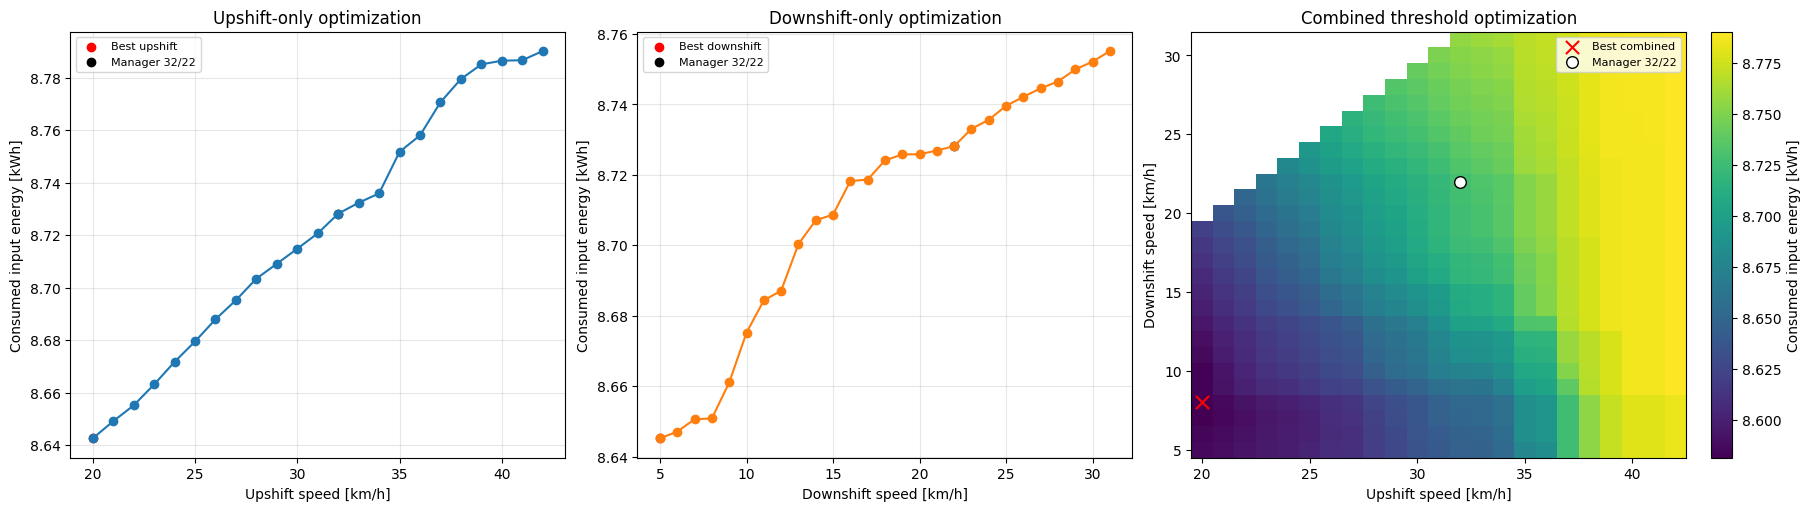

,Optimization case,Upshift [km/h],Downshift [km/h],Consumed input energy [kWh],Energy change vs manager [Wh]
0,Manager baseline,32.0,22.0,8.728172,0.000000
1,Upshift-only optimum,20.0,22.0,8.642576,-85.596527
2,Downshift-only optimum,32.0,5.0,8.645185,-82.987072
3,Combined optimum,20.0,8.0,8.581393,-146.779790


Optimization validation passed: every combined candidate has downshift speed below upshift speed.


In [ ]:
manager_upshift_speed = 32.0
manager_downshift_speed = 22.0

# Case 1: optimize only upshift speed while downshift remains at 22 km/h.
upshift_optimization_speeds = np.arange(20.0, 43.0, 1.0)
upshift_optimization = pd.DataFrame([
    {
        "Upshift [km/h]": candidate_upshift,
        "Downshift [km/h]": manager_downshift_speed,
        "Consumed input energy [kWh]": calculate_cycle_energy_for_shift(
            candidate_upshift,
            manager_downshift_speed,
        )["consumed_energy_kwh"],
    }
    for candidate_upshift in upshift_optimization_speeds
])
best_upshift_row = upshift_optimization.loc[upshift_optimization["Consumed input energy [kWh]"].idxmin()]

# Case 2: optimize only downshift speed while upshift remains at 32 km/h.
downshift_optimization_speeds = np.arange(5.0, manager_upshift_speed, 1.0)
downshift_optimization = pd.DataFrame([
    {
        "Upshift [km/h]": manager_upshift_speed,
        "Downshift [km/h]": candidate_downshift,
        "Consumed input energy [kWh]": calculate_cycle_energy_for_shift(
            manager_upshift_speed,
            candidate_downshift,
        )["consumed_energy_kwh"],
    }
    for candidate_downshift in downshift_optimization_speeds
])
best_downshift_row = downshift_optimization.loc[downshift_optimization["Consumed input energy [kWh]"].idxmin()]

# Case 3: optimize both thresholds together.
combined_upshift_speeds = np.arange(20.0, 43.0, 1.0)
combined_downshift_speeds = np.arange(5.0, 32.0, 1.0)
combined_rows = []
for candidate_upshift in combined_upshift_speeds:
    for candidate_downshift in combined_downshift_speeds:
        if candidate_downshift >= candidate_upshift:
            continue
        candidate_result = calculate_cycle_energy_for_shift(
            candidate_upshift,
            candidate_downshift,
        )
        combined_rows.append({
            "Upshift [km/h]": candidate_upshift,
            "Downshift [km/h]": candidate_downshift,
            "Consumed input energy [kWh]": candidate_result["consumed_energy_kwh"],
            "Valid": candidate_result["valid"],
            "Upshifts": candidate_result["upshift_events"],
            "Downshifts": candidate_result["downshift_events"],
        })

combined_optimization = pd.DataFrame(combined_rows)
combined_valid = combined_optimization.loc[combined_optimization["Valid"]].copy()
best_combined_row = combined_valid.loc[combined_valid["Consumed input energy [kWh]"].idxmin()]

manager_result = calculate_cycle_energy_for_shift(
    manager_upshift_speed,
    manager_downshift_speed,
)
manager_energy = manager_result["consumed_energy_kwh"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
axes[0].plot(upshift_optimization["Upshift [km/h]"], upshift_optimization["Consumed input energy [kWh]"], marker="o")
axes[0].scatter(best_upshift_row["Upshift [km/h]"], best_upshift_row["Consumed input energy [kWh]"], color="red", label="Best upshift")
axes[0].scatter(manager_upshift_speed, manager_energy, color="black", label="Manager 32/22")
axes[0].set_title("Upshift-only optimization")
axes[0].set_xlabel("Upshift speed [km/h]")
axes[0].set_ylabel("Consumed input energy [kWh]")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(downshift_optimization["Downshift [km/h]"], downshift_optimization["Consumed input energy [kWh]"], marker="o", color="tab:orange")
axes[1].scatter(best_downshift_row["Downshift [km/h]"], best_downshift_row["Consumed input energy [kWh]"], color="red", label="Best downshift")
axes[1].scatter(manager_downshift_speed, manager_energy, color="black", label="Manager 32/22")
axes[1].set_title("Downshift-only optimization")
axes[1].set_xlabel("Downshift speed [km/h]")
axes[1].set_ylabel("Consumed input energy [kWh]")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

energy_grid = combined_valid.pivot(index="Downshift [km/h]", columns="Upshift [km/h]", values="Consumed input energy [kWh]")
heatmap = axes[2].pcolormesh(energy_grid.columns, energy_grid.index, energy_grid.to_numpy(), shading="auto", cmap="viridis")
axes[2].scatter(best_combined_row["Upshift [km/h]"], best_combined_row["Downshift [km/h]"], color="red", marker="x", s=90, label="Best combined")
axes[2].scatter(manager_upshift_speed, manager_downshift_speed, color="white", edgecolor="black", s=70, label="Manager 32/22")
axes[2].set_title("Combined threshold optimization")
axes[2].set_xlabel("Upshift speed [km/h]")
axes[2].set_ylabel("Downshift speed [km/h]")
axes[2].legend(fontsize=8)
fig.colorbar(heatmap, ax=axes[2], label="Consumed input energy [kWh]")

plt.show()

optimization_summary_df = pd.DataFrame([
    {
        "Optimization case": "Manager baseline",
        "Upshift [km/h]": manager_upshift_speed,
        "Downshift [km/h]": manager_downshift_speed,
        "Consumed input energy [kWh]": manager_energy,
    },
    {
        "Optimization case": "Upshift-only optimum",
        "Upshift [km/h]": best_upshift_row["Upshift [km/h]"],
        "Downshift [km/h]": best_upshift_row["Downshift [km/h]"],
        "Consumed input energy [kWh]": best_upshift_row["Consumed input energy [kWh]"],
    },
    {
        "Optimization case": "Downshift-only optimum",
        "Upshift [km/h]": best_downshift_row["Upshift [km/h]"],
        "Downshift [km/h]": best_downshift_row["Downshift [km/h]"],
        "Consumed input energy [kWh]": best_downshift_row["Consumed input energy [kWh]"],
    },
    {
        "Optimization case": "Combined optimum",
        "Upshift [km/h]": best_combined_row["Upshift [km/h]"],
        "Downshift [km/h]": best_combined_row["Downshift [km/h]"],
        "Consumed input energy [kWh]": best_combined_row["Consumed input energy [kWh]"],
    },
])
optimization_summary_df["Energy change vs manager [Wh]"] = (
    optimization_summary_df["Consumed input energy [kWh]"] - manager_energy
) * 1000.0
display(optimization_summary_df)

assert manager_downshift_speed < manager_upshift_speed
assert all(combined_valid["Downshift [km/h]"] < combined_valid["Upshift [km/h]"])
print("Optimization validation passed: every combined candidate has downshift speed below upshift speed.")

## 16. Plot the sweep results

## 17. Plot the optimum shift strategy

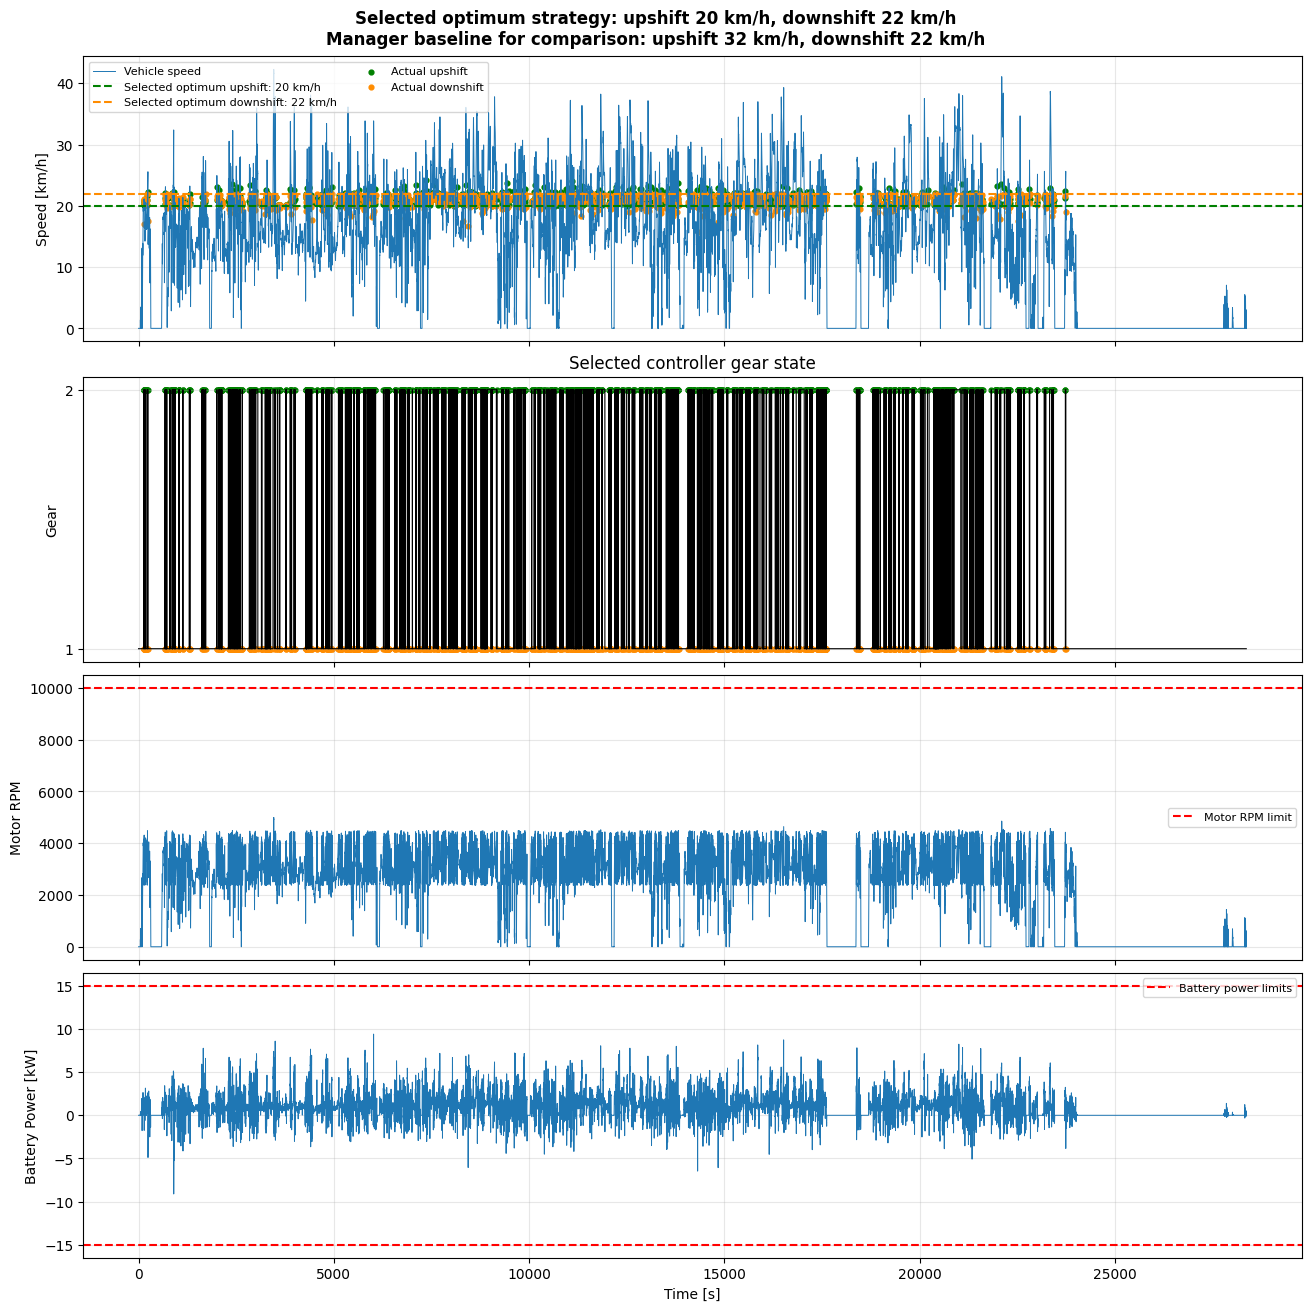

Selected optimum: upshift 20 km/h, downshift 22 km/h
Manager baseline: upshift 32 km/h, downshift 22 km/h
Actual events in selected optimum: 1384 upshifts, 1384 downshifts


In [ ]:
if not valid_results.empty:
    best_shift_speed = float(best_row["Upshift Speed [km/h]"])
    best_downshift_speed = float(best_row["Downshift Speed [km/h]"])
    best_result = calculate_cycle_energy_for_shift(
        best_shift_speed,
        best_downshift_speed,
    )

    best_shift_indices = np.flatnonzero(np.diff(best_result["gear"]) != 0)
    best_upshift_indices = best_shift_indices[best_result["gear"][best_shift_indices + 1] == 2]
    best_downshift_indices = best_shift_indices[best_result["gear"][best_shift_indices + 1] == 1]

    fig, ax = plt.subplots(4, 1, figsize=(13, 13), sharex=True, constrained_layout=True)

    ax[0].plot(time, speed_kmh, linewidth=0.7, label="Vehicle speed")
    ax[0].axhline(
        best_shift_speed,
        color="green",
        linestyle="--",
        label=f"Selected optimum upshift: {best_shift_speed:g} km/h",
    )
    ax[0].axhline(
        best_downshift_speed,
        color="darkorange",
        linestyle="--",
        label=f"Selected optimum downshift: {best_downshift_speed:g} km/h",
    )
    ax[0].scatter(time[best_upshift_indices + 1], speed_kmh[best_upshift_indices + 1], color="green", s=12, label="Actual upshift")
    ax[0].scatter(time[best_downshift_indices + 1], speed_kmh[best_downshift_indices + 1], color="darkorange", s=12, label="Actual downshift")
    ax[0].set_ylabel("Speed [km/h]")
    ax[0].legend(fontsize=8, ncol=2)

    ax[1].step(time, best_result["gear"], where="post", color="black", linewidth=0.8)
    ax[1].scatter(time[best_upshift_indices + 1], np.full(len(best_upshift_indices), 2), color="green", s=12)
    ax[1].scatter(time[best_downshift_indices + 1], np.full(len(best_downshift_indices), 1), color="darkorange", s=12)
    ax[1].set_ylabel("Gear")
    ax[1].set_yticks([1, 2])
    ax[1].set_title("Selected controller gear state")

    ax[2].plot(time, best_result["selected_motor_rpm"], linewidth=0.7)
    ax[2].axhline(motor_max_rpm, color="red", linestyle="--", label="Motor RPM limit")
    ax[2].set_ylabel("Motor RPM")
    ax[2].legend(fontsize=8)

    ax[3].plot(time, best_result["battery_power"] / 1000.0, linewidth=0.7)
    ax[3].axhline(battery_max_power / 1000.0, color="red", linestyle="--", label="Battery power limits")
    ax[3].axhline(-battery_max_power / 1000.0, color="red", linestyle="--")
    ax[3].set_ylabel("Battery Power [kW]")
    ax[3].set_xlabel("Time [s]")
    ax[3].legend(fontsize=8)

    for axis in ax:
        axis.grid(True, alpha=0.3)

    fig.suptitle(
        f"Selected optimum strategy: upshift {best_shift_speed:g} km/h, downshift {best_downshift_speed:g} km/h\n"
        f"Manager baseline for comparison: upshift 32 km/h, downshift 22 km/h",
        fontweight="bold",
    )
    plt.show()

    print(f"Selected optimum: upshift {best_shift_speed:g} km/h, downshift {best_downshift_speed:g} km/h")
    print(f"Manager baseline: upshift 32 km/h, downshift 22 km/h")
    print(f"Actual events in selected optimum: {len(best_upshift_indices)} upshifts, {len(best_downshift_indices)} downshifts")

## 18. Export all results

The validated sweep table is exported after the manual checks and final strategy plot.

In [ ]:
output_csv = cycle_file.parent / "N603_two_speed_shift_sweep_results.csv"
results_df.to_csv(output_csv, index=False)
print(f"Results saved to: {output_csv}")

Results saved to: <path-removed>